# JOILang PromptOps: Local Model Benchmark & Render Trace

이 노트북은 JOILang-Server 저장소의 `run_benchmark.py`를 활용하여 실제 로컬 모델 환경에서 blocks 기반 프롬프트 렌더링이 어떻게 동작하는지 한 단계씩 점검하기 위한 디버깅 및 트레이싱 도구입니다.

주요 목적:
1. 로컬 환경 변수 설정 및 단일 행(Row 1) 테스트 파이프라인 정상 구동 확인
2. blocks 렌더링과 legacy_v13_monolith 렌더링 비교
3. Retrieval Pre-mapping 옵션에 따른 동작 확인
4. 생성된 결과 아티팩트(`row_comparison.csv` 등)를 로드하여 검증 결과(DET 점수, 지연 시간, 토큰 수 등) 확인

> 참고: 이 노트북은 전체 모델 비교 실험을 돌리기 위한 것이 아니라, 본격적인 대규모 실험 전 환경과 프롬프트 렌더링 파이프라인을 점검하는 용도입니다.

## Section 1. 환경 변수 및 경로 설정
제공된 가이드에 따라 Conda 가상환경 파이썬과 타겟 GPU 디바이스를 설정합니다.

In [2]:
import os
import sys
import subprocess
from pathlib import Path

import pandas as pd
from IPython.display import display

# 작업 디렉토리 기준 경로 설정
NOTEBOOK_DIR = Path.cwd().resolve()
VERSION_ROOT = NOTEBOOK_DIR.parent
REPO_ROOT = VERSION_ROOT.parent.parent

# 환경 변수 설정 (로컬 환경에 맞게 수정 가능)
os.environ["JOI_V15_WORKER_PYTHON"] = "/home/mgjeong/miniconda3/envs/l/bin/python"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"

# 실행할 파이썬 스크립트 경로
RUN_BENCHMARK_SCRIPT = VERSION_ROOT / "scripts" / "run_benchmark.py"

# 벤치마크 CLI를 실행할 Python. 보통 현재 Jupyter kernel의 Python을 사용합니다.
# 필요하면 아래 값을 직접 수정하세요. 예: "/home/mgjeong/miniconda3/envs/l/bin/python"
BENCHMARK_PYTHON = sys.executable

print("[Paths]")
print(f"REPO_ROOT: {REPO_ROOT}")
print(f"VERSION_ROOT: {VERSION_ROOT}")
print(f"RUN_BENCHMARK_SCRIPT: {RUN_BENCHMARK_SCRIPT}")

print("\n[Environment Variables]")
print(f"WORKER_PYTHON: {os.environ.get('JOI_V15_WORKER_PYTHON')}")
print(f"LOCAL_DEVICE: {os.environ.get('JOI_V15_LOCAL_DEVICE')}")
print(f"BENCHMARK_PYTHON: {BENCHMARK_PYTHON}")

if not RUN_BENCHMARK_SCRIPT.exists():
    print(f"\n[Warning] run_benchmark.py를 찾지 못했습니다: {RUN_BENCHMARK_SCRIPT}")

[Paths]
REPO_ROOT: /root/llm/JOILang-Server
VERSION_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413
RUN_BENCHMARK_SCRIPT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py

[Environment Variables]
WORKER_PYTHON: /home/mgjeong/miniconda3/envs/l/bin/python
LOCAL_DEVICE: cuda:0
BENCHMARK_PYTHON: /usr/bin/python3


In [71]:
import os
from pathlib import Path

# 잘못된 model override 제거
os.environ.pop("JOI_V15_LOCAL_MODEL_NAME", None)
os.environ.pop("JOI_V14_LOCAL_MODEL_NAME", None)

# 모델별 자동 매핑을 위한 base dir
os.environ["JOI_V15_LOCAL_MODEL_BASE_DIR"] = "/root/llm/JOILang-Server/local_models"

# 실행 환경
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"
os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"

# 권장: 새 subprocess에서 즉시 출력
os.environ["PYTHONUNBUFFERED"] = "1"

# 확인
for k in [
    "JOI_V15_LOCAL_MODEL_NAME",
    "JOI_V14_LOCAL_MODEL_NAME",
    "JOI_V15_LOCAL_MODEL_BASE_DIR",
    "JOI_V15_LOCAL_DEVICE",
    "JOI_V15_WORKER_PYTHON",
]:
    print(k, "=", os.environ.get(k))

JOI_V15_LOCAL_MODEL_NAME = None
JOI_V14_LOCAL_MODEL_NAME = None
JOI_V15_LOCAL_MODEL_BASE_DIR = /root/llm/JOILang-Server/local_models
JOI_V15_LOCAL_DEVICE = cuda:0
JOI_V15_WORKER_PYTHON = /root/llm/je/bin/python


## Section 2. 유틸리티 함수: 벤치마크 실행 및 최근 실행 결과 불러오기
벤치마크 스크립트 실행 후 `results/model_suite_<timestamp>` 폴더에 생성되는 CSV를 자동으로 읽어오기 위한 헬퍼 함수입니다.

In [3]:
def run_benchmark(extra_args, *, cwd=None):
    """run_benchmark.py를 subprocess로 실행합니다."""
    if not RUN_BENCHMARK_SCRIPT.exists():
        raise FileNotFoundError(f"run_benchmark.py not found: {RUN_BENCHMARK_SCRIPT}")

    cmd = [BENCHMARK_PYTHON, str(RUN_BENCHMARK_SCRIPT), *map(str, extra_args)]
    print("Running command:")
    print(" ".join(cmd))
    print()

    completed = subprocess.run(
        cmd,
        cwd=str(cwd or VERSION_ROOT),
        env=os.environ.copy(),
        text=True,
        check=False,
    )
    if completed.returncode != 0:
        raise RuntimeError(f"Benchmark failed with exit code {completed.returncode}")
    return completed


def get_latest_result_dir(version_root):
    results_dir = Path(version_root) / "results"
    if not results_dir.exists():
        return None

    subdirs = [
        d for d in results_dir.iterdir()
        if d.is_dir() and d.name.startswith("model_suite_")
    ]
    if not subdirs:
        return None

    return max(subdirs, key=lambda p: p.stat().st_mtime)


def inspect_latest_row_comparison(version_root):
    latest_dir = get_latest_result_dir(version_root)
    if latest_dir is None:
        print("No results directory found.")
        return None

    csv_path = latest_dir / "row_comparison.csv"
    if not csv_path.exists():
        print(f"row_comparison.csv not found in {latest_dir}")
        return None

    print(f"Loading results from: {csv_path}")
    df = pd.read_csv(csv_path)

    # 핵심 확인 지표 필터링
    preferred_cols = [
        "row_no",
        "model_key",
        "det_score",
        "is_pass",
        "failure_reasons",
        "prompt_tokens",
        "latency",
        "generated_code",
    ]
    target_cols = [col for col in preferred_cols if col in df.columns]
    if not target_cols:
        return df
    return df[target_cols]


## Section 3. [Recommended] 초기 Blocks Render 및 로컬 모델 테스트
가장 목적에 부합하는 권장 진입점입니다. `qwen25_coder_7b`로 Row 1에 대해 blocks 렌더링 및 Retrieval Pre-mapping 옵션을 켜서 실행합니다.

체크리스트:
1. Generated JOICode가 비어 있지 않은가?
2. JSON valid인가?
3. DET 점수는 얼마인가?
4. failure reason이 무엇인가?
5. prompt tokens가 얼마인가?
6. LLM latency가 찍히는가?

In [11]:
#MODEL="phi35_mini"

In [10]:
#MODEL="gemma2_9b_it"  #Gemma2 9B-it의 컨텍스트 한계 8192를 훨씬 넘는 20800 tokens 프롬프트

/home/mgjeong/miniconda3/envs/l/bin/python - <<'PY'
> from transformers import AutoConfig
> 
> model_path = "/home/mgjeong/.cache/huggingface/hub/models--google--gemma-2-9b-it/snapshots/11c9b309abf73637e4b6f9a3fa1e92e615547819"
> cfg = AutoConfig.from_pretrained(model_path, local_files_only=True)
> 
> for key in [
>     "max_position_embeddings",
>     "sliding_window",
>     "rope_theta",
>     "model_type",
>     "architectures",
> ]:
>     print(key, "=", getattr(cfg, key, None))
> PY

huggingface-cli login 

pip install   transformers==4.35.*   sentence-transformers==2.2.2   huggingface_hub==0.19.*



In [ ]:
#MODEL="qwen25_coder_7b"
#MODEL="llama31_8b" 
#MODEL="qwen25_coder_14b"

# Debuding 
# rm -f /tmp/joi_local_llm_worker_debug.log
# ~~
# tail -300 /tmp/joi_local_llm_worker_debug.log

In [8]:
print("Running basic block render test on qwen25_coder_14b (Row 1)...")

run_benchmark([
    "--suite", "paper_local5",
    "--model-key", "phi35_mini",
    "--row-no", "1",
    "--candidate-k", "1",
    "--repair-attempts", "0",
    "--det-profile", "strict",
    "--prompt-render-mode", "blocks",
    "--enable-retrieval-premapping",
    "--retrieval-topk", "10",
    "--retrieval-device", "cpu",
    "--print-mode", "compare",
    "--strict-availability",
])

Running basic block render test on qwen25_coder_14b (Row 1)...
Running command:
/usr/bin/python3 /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key phi35_mini --row-no 1 --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-device cpu --print-mode compare --strict-availability

Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518_181408
Rows: 1 | Models: phi35_mini
 - phi35_mini (Phi-3.5-mini-instruct): avg_det=0.0000, gt_exact=0/1, pass=0/1, avg_latency=0.0000s, warm_p50=0.0000s, cold_load=0.0000s, avg_prompt_tokens=0.0, peak_vram=0.0000GB, gen_errors=1
   top_generation_error: failed to start persistent worker: FileNotFoundError: [Errno 2] No such file or directory: '/home/mgjeong/miniconda3/envs/l/bin/python'
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/version0_15_upd

CompletedProcess(args=['/usr/bin/python3', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py', '--suite', 'paper_local5', '--model-key', 'phi35_mini', '--row-no', '1', '--candidate-k', '1', '--repair-attempts', '0', '--det-profile', 'strict', '--prompt-render-mode', 'blocks', '--enable-retrieval-premapping', '--retrieval-topk', '10', '--retrieval-device', 'cpu', '--print-mode', 'compare', '--strict-availability'], returncode=0)

In [7]:
import os
from pathlib import Path

LOCAL_MODELS_DIR = Path("/root/llm/JOILang-Server/local_models").resolve()
os.environ["JOI_V15_LOCAL_MODEL_NAME"] = str(LOCAL_MODELS_DIR / "qwen25_coder_7b")
os.environ["JOI_V15_LOCAL_FILES_ONLY"] = "true"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

run_benchmark([
    "--suite", "paper_local5",
    "--model-key", "qwen25_coder_7b",
    "--row-no", "1",
    "--candidate-k", "1",
    "--repair-attempts", "0",
    "--det-profile", "strict",
    "--prompt-render-mode", "blocks",
    "--enable-retrieval-premapping",
    "--retrieval-topk", "10",
    "--retrieval-device", "cpu",
    "--print-mode", "compare",
    "--strict-availability",
])

Running command:
/usr/bin/python3 /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_7b --row-no 1 --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-device cpu --print-mode compare --strict-availability

Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518_181356
Rows: 1 | Models: qwen25_coder_7b
 - qwen25_coder_7b (Qwen2.5-Coder-7B-Instruct): avg_det=0.0000, gt_exact=0/1, pass=0/1, avg_latency=0.0000s, warm_p50=0.0000s, cold_load=0.0000s, avg_prompt_tokens=0.0, peak_vram=0.0000GB, gen_errors=1
   top_generation_error: failed to start persistent worker: FileNotFoundError: [Errno 2] No such file or directory: '/home/mgjeong/miniconda3/envs/l/bin/python'
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518_181

CompletedProcess(args=['/usr/bin/python3', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py', '--suite', 'paper_local5', '--model-key', 'qwen25_coder_7b', '--row-no', '1', '--candidate-k', '1', '--repair-attempts', '0', '--det-profile', 'strict', '--prompt-render-mode', 'blocks', '--enable-retrieval-premapping', '--retrieval-topk', '10', '--retrieval-device', 'cpu', '--print-mode', 'compare', '--strict-availability'], returncode=0)

In [ ]:
# 위 셀 실행 후 생성된 결과를 데이터프레임으로 확인
df_result_1 = inspect_latest_row_comparison(VERSION_ROOT)
if df_result_1 is not None:
    display(df_result_1)

## Section 4. Full Schema Fallback (Retrieval 끄기) 테스트
Retrieval pre-mapping 없이 전체 스키마를 포함시켜 렌더링합니다. 프롬프트가 길어지므로 토큰 수와 latency 증가를 관찰할 수 있습니다.

In [6]:
print("Running Full Schema Fallback test...")

run_benchmark([
    "--suite", "paper_local5",
    "--model-key", "qwen25_coder_7b",
    "--row-no", "1",
    "--candidate-k", "1",
    "--repair-attempts", "0",
    "--det-profile", "strict",
    "--prompt-render-mode", "blocks",
    "--disable-retrieval-premapping",
    "--print-mode", "compare",
    "--strict-availability",
])

Running Full Schema Fallback test...
Running command:
/usr/bin/python3 /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_7b --row-no 1 --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --disable-retrieval-premapping --print-mode compare --strict-availability

Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518_181350
Rows: 1 | Models: qwen25_coder_7b
 - qwen25_coder_7b (Qwen2.5-Coder-7B-Instruct): avg_det=0.0000, gt_exact=0/1, pass=0/1, avg_latency=0.0000s, warm_p50=0.0000s, cold_load=0.0000s, avg_prompt_tokens=0.0, peak_vram=0.0000GB, gen_errors=1
   top_generation_error: failed to start persistent worker: FileNotFoundError: [Errno 2] No such file or directory: '/home/mgjeong/miniconda3/envs/l/bin/python'
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518_181350/s

CompletedProcess(args=['/usr/bin/python3', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py', '--suite', 'paper_local5', '--model-key', 'qwen25_coder_7b', '--row-no', '1', '--candidate-k', '1', '--repair-attempts', '0', '--det-profile', 'strict', '--prompt-render-mode', 'blocks', '--disable-retrieval-premapping', '--print-mode', 'compare', '--strict-availability'], returncode=0)

In [ ]:
df_result_full_schema = inspect_latest_row_comparison(VERSION_ROOT)
if df_result_full_schema is not None:
    display(df_result_full_schema)

## Section 5. Legacy Monolith (v13) vs Blocks (v15) 렌더링 모드 비교
`legacy_v13_monolith` 모드를 실행합니다. 이후 Section 3의 blocks 결과와 비교해볼 수 있습니다.

참고: 이 테스트를 위해서는 `version0_13` 디렉토리에 프롬프트 에셋이 존재해야 합니다.

In [ ]:
print("Running Legacy Monolith test...")

prompt_assets_dir = REPO_ROOT / "gpt_mg" / "version0_13"
print(f"prompt_assets_dir: {prompt_assets_dir}")

run_benchmark([
    "--suite", "paper_local5",
    "--model-key", "qwen25_coder_7b",
    "--row-no", "1",
    "--candidate-k", "1",
    "--repair-attempts", "0",
    "--det-profile", "strict",
    "--prompt-render-mode", "legacy_v13_monolith",
    "--prompt-assets-dir", str(prompt_assets_dir),
    "--enable-retrieval-premapping",
    "--retrieval-topk", "10",
    "--retrieval-device", "cpu",
    "--print-mode", "compare",
    "--strict-availability",
])

In [ ]:
df_result_legacy = inspect_latest_row_comparison(VERSION_ROOT)
if df_result_legacy is not None:
    display(df_result_legacy)

## Section 6. 스케일업: 카테고리 및 여러 행 실행 예시
Row 1이 성공적으로 실행된다면, 본격적인 진화를 위해 여러 행을 평가할 수 있습니다.
아래 명령은 `--category 1`과 `--category 2`에 대해 카테고리당 3개씩, 총 6개의 데이터를 평가합니다.

실행 시간이 길어질 수 있으므로 기본적으로 주석 처리되어 있습니다. 필요 시 주석을 해제한 뒤 실행하세요.

In [ ]:
# 필요 시 아래 블록의 주석을 해제하고 실행하세요.
#
# print("Running multi-row category test...")
# run_benchmark([
#     "--suite", "paper_local5",
#     "--model-key", "qwen25_coder_7b",
#     "--category", "1",
#     "--category", "2",
#     "--limit-per-category", "3",
#     "--candidate-k", "1",
#     "--repair-attempts", "0",
#     "--det-profile", "strict",
#     "--prompt-render-mode", "blocks",
#     "--enable-retrieval-premapping",
#     "--retrieval-topk", "10",
#     "--retrieval-device", "cpu",
#     "--print-mode", "summary",
#     "--strict-availability",
# ])

print("주석을 해제하면 multi-row test를 실행할 수 있습니다.")

## Section 7. 결과 아티팩트 디렉토리 점검
가장 최근 실행된 결과 디렉토리 내에 HTML/PDF 리포트 및 각종 요약 CSV가 정상적으로 생성되었는지 확인합니다.

In [ ]:
latest_dir = get_latest_result_dir(VERSION_ROOT)
if latest_dir:
    print(f"Latest Result Directory: {latest_dir.name}\n")
    print("--- Contained Files & Reports ---")
    for item in latest_dir.rglob("*"):
        if item.is_file():
            # 너무 긴 경로는 상대 경로로 잘라서 표기
            rel_path = item.relative_to(latest_dir)
            print(f"- {rel_path}")
else:
    print("No result directory to inspect.")

# [Real Test]

## Local Inference Model 

In [72]:
from pathlib import Path

base = Path("/root/llm/JOILang-Server/local_models")

for name in [
    "qwen25_coder_7b",
    "llama31_8b",
    "qwen25_coder_14b",
]:
    p = base / name
    print(name, p.exists(), p)

qwen25_coder_7b True /root/llm/JOILang-Server/local_models/qwen25_coder_7b
llama31_8b True /root/llm/JOILang-Server/local_models/llama31_8b
qwen25_coder_14b True /root/llm/JOILang-Server/local_models/qwen25_coder_14b


In [1]:
from pathlib import Path
import subprocess
import os
from datetime import datetime

REPO = Path("/root/llm/JOILang-Server")
SCRIPT = REPO / "gpt_mg/version0_15_update20260413/scripts/run_benchmark.py"

os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"

def run_blocks_full(model_key: str):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = REPO / f"gpt_mg/version0_15_update20260413/results/block_render_full_{model_key}_{ts}"

    cmd = [
        "python", "-u", str(SCRIPT),
        "--suite", "paper_local5",
        "--model-key", model_key,
        "--candidate-k", "1",
        "--repair-attempts", "0",
        "--det-profile", "strict",
        "--prompt-render-mode", "blocks",
        "--enable-retrieval-premapping",
        "--retrieval-topk", "10",
        "--retrieval-mode", "hybrid",
        "--retrieval-device", "cpu",
        "--measure-latency",
        "--measure-vram",
        "--paper-fair-mode",
        "--export-paper-artifacts",
        "--print-mode", "summary",
        "--strict-availability",
        "--output-dir", str(out),
    ]

    print(" ".join(cmd))
    subprocess.run(cmd, cwd=REPO, check=True)
    return out

In [12]:
out_qwen7 = run_blocks_full("qwen25_coder_7b")

python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_7b --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-mode hybrid --retrieval-device cpu --measure-latency --measure-vram --paper-fair-mode --export-paper-artifacts --print-mode summary --strict-availability --output-dir /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_full_qwen25_coder_7b_20260515_160027
Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_full_qwen25_coder_7b_20260515_160027
Rows: 280 | Models: qwen25_coder_7b
 - qwen25_coder_7b (Qwen2.5-Coder-7B-Instruct): avg_det=79.9240, gt_exact=58/280, pass=156/280, avg_latency=4.8305s, warm_p50=5.0524s, cold_load=14.5697s, avg_prompt_tokens=27952.6, peak_vram=22.0304GB
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/ve

In [10]:
out_qwen7

PosixPath('/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_full_qwen25_coder_7b_20260515_145402')

In [13]:
out_llama = run_blocks_full("llama31_8b")

python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key llama31_8b --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-mode hybrid --retrieval-device cpu --measure-latency --measure-vram --paper-fair-mode --export-paper-artifacts --print-mode summary --strict-availability --output-dir /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_full_llama31_8b_20260515_163211
Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_full_llama31_8b_20260515_163211
Rows: 280 | Models: llama31_8b
 - llama31_8b (Llama-3.1-8B-Instruct): avg_det=0.0000, gt_exact=0/280, pass=0/280, avg_latency=0.0000s, warm_p50=0.0000s, cold_load=0.0000s, avg_prompt_tokens=0.0, peak_vram=0.0000GB, gen_errors=280
   top_generation_error: We couldn't connect to 'https://huggingface.co' to 

In [5]:
import os
from pathlib import Path

LOCAL_MODELS_DIR = Path("/root/llm/JOILang-Server/local_models").resolve()
os.environ["JOI_V15_LOCAL_MODEL_NAME"] = str(LOCAL_MODELS_DIR / "qwen25_coder_14b")
os.environ["JOI_V15_LOCAL_FILES_ONLY"] = "true"
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

run_benchmark([
    "--suite", "paper_local5",
    "--model-key", "qwen25_coder_14b",
    "--row-no", "1",
    "--candidate-k", "1",
    "--repair-attempts", "0",
    "--det-profile", "strict",
    "--prompt-render-mode", "blocks",
    "--enable-retrieval-premapping",
    "--retrieval-topk", "10",
    "--retrieval-device", "cpu",
    "--print-mode", "compare",
    "--strict-availability",
])

Running command:
/usr/bin/python3 /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_14b --row-no 1 --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-device cpu --print-mode compare --strict-availability

Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518_181305
Rows: 1 | Models: qwen25_coder_14b
 - qwen25_coder_14b (Qwen2.5-Coder-14B-Instruct): avg_det=0.0000, gt_exact=0/1, pass=0/1, avg_latency=0.0000s, warm_p50=0.0000s, cold_load=0.0000s, avg_prompt_tokens=0.0, peak_vram=0.0000GB, gen_errors=1
   top_generation_error: failed to start persistent worker: FileNotFoundError: [Errno 2] No such file or directory: '/home/mgjeong/miniconda3/envs/l/bin/python'
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/model_suite_20260518

CompletedProcess(args=['/usr/bin/python3', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py', '--suite', 'paper_local5', '--model-key', 'qwen25_coder_14b', '--row-no', '1', '--candidate-k', '1', '--repair-attempts', '0', '--det-profile', 'strict', '--prompt-render-mode', 'blocks', '--enable-retrieval-premapping', '--retrieval-topk', '10', '--retrieval-device', 'cpu', '--print-mode', 'compare', '--strict-availability'], returncode=0)

In [ ]:
out_qwen14 = run_blocks_full("qwen25_coder_14b")

python -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_14b --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-mode hybrid --retrieval-device cpu --measure-latency --measure-vram --paper-fair-mode --export-paper-artifacts --print-mode summary --strict-availability --output-dir /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_full_qwen25_coder_14b_20260515_165037


## 2. Cloud GPT-4.1-mini blocks render 실행

cloud reference도 같은 방식으로 저장해두고 비교하려면, suite만 paper_with_cloud_ref로 바꾸고 model-key를 gpt41_mini로 지정하면 됩니다. run_benchmark.py는 실제로 run_model_suite_benchmark.py의 entrypoint를 호출하고, 그 안에 paper_with_cloud_ref = paper_local5 + GPT-4.1-mini suite가 정의

In [ ]:
from pathlib import Path
import subprocess
import os
from datetime import datetime
import pandas as pd
import json

REPO = Path("/root/llm/JOILang-Server")
SCRIPT = REPO / "gpt_mg/version0_15_update20260413/scripts/run_benchmark.py"

os.environ["JOI_V15_WORKER_PYTHON"] = "/home/mgjeong/miniconda3/envs/l/bin/python"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"

# OpenAI-compatible endpoint가 이미 떠 있어야 합니다.
# 예: export JOI_V15_OPENAI_ENDPOINT="http://127.0.0.1:8000/v1/chat/completions"
OPENAI_ENDPOINT = os.environ.get("JOI_V15_OPENAI_ENDPOINT", "http://127.0.0.1:8000/v1/chat/completions")

In [ ]:
def run_cloud_blocks_full(
    row_no=None,
    categories=None,
    limit_per_category=None,
    output_prefix="cloud_blocks_full",
):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = REPO / f"gpt_mg/version0_15_update20260413/results/{output_prefix}_gpt41_mini_{ts}"

    cmd = [
        "python", "-u", str(SCRIPT),
        "--suite", "paper_with_cloud_ref",
        "--model-key", "gpt41_mini",
        "--llm-mode", "openai",
        "--llm-endpoint", OPENAI_ENDPOINT,
        "--candidate-k", "1",
        "--repair-attempts", "0",
        "--det-profile", "strict",
        "--prompt-render-mode", "blocks",
        "--enable-retrieval-premapping",
        "--retrieval-topk", "10",
        "--retrieval-mode", "hybrid",
        "--retrieval-device", "cpu",
        "--print-mode", "summary",
        "--output-dir", str(out),
    ]

    if row_no is not None:
        cmd += ["--row-no", str(row_no)]

    if categories:
        for cat in categories:
            cmd += ["--category", str(cat)]

    if limit_per_category is not None:
        cmd += ["--limit-per-category", str(limit_per_category)]

    print(" ".join(cmd))
    subprocess.run(cmd, cwd=REPO, check=True)

    return out

In [ ]:
# Row 1만 cloud blocks render로 확인
out_cloud_row1 = run_cloud_blocks_full(row_no=1, output_prefix="cloud_blocks_row1")

In [ ]:
# 전체 dataset cloud blocks render
out_cloud_full = run_cloud_blocks_full(output_prefix="cloud_blocks_full")

In [ ]:
# category별 일부만 먼저 확인
out_cloud_cat12 = run_cloud_blocks_full(
    categories=[1, 2],
    limit_per_category=5,
    output_prefix="cloud_blocks_cat12"
)

### 3. 결과확인

In [ ]:
import pandas as pd
from pathlib import Path

def inspect_result(out_dir):
    out_dir = Path(out_dir)

    print("OUT:", out_dir)

    files = [
        "suite_summary.csv",
        "main_model_comparison.csv",
        "tradeoff_summary.csv",
        "latency_summary.csv",
        "vram_summary.csv",
        "tokenizer_summary.csv",
        "paper_metrics_summary.json",
        "row_comparison.csv",
        "failure_reason_summary.csv",
        "category_summary.csv",
    ]

    for f in files:
        p = out_dir / f
        print(f, "OK" if p.exists() else "MISSING")

    summary = out_dir / "suite_summary.csv"
    if summary.exists():
        display(pd.read_csv(summary))

    main = out_dir / "main_model_comparison.csv"
    if main.exists():
        display(pd.read_csv(main))

    failure = out_dir / "failure_reason_summary.csv"
    if failure.exists():
        display(pd.read_csv(failure).head(20))

    category = out_dir / "category_summary.csv"
    if category.exists():
        display(pd.read_csv(category))

In [ ]:
# Cloud legacy monolith도 비교하고 싶을 때
def run_cloud_legacy_full(
    row_no=None,
    categories=None,
    limit_per_category=None,
    output_prefix="cloud_legacy_full",
):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = REPO / f"gpt_mg/version0_15_update20260413/results/{output_prefix}_gpt41_mini_{ts}"

    prompt_assets = REPO / "gpt_mg/version0_13"

    cmd = [
        "python", "-u", str(SCRIPT),
        "--suite", "paper_with_cloud_ref",
        "--model-key", "gpt41_mini",
        "--llm-mode", "openai",
        "--llm-endpoint", OPENAI_ENDPOINT,
        "--candidate-k", "1",
        "--repair-attempts", "0",
        "--det-profile", "strict",
        "--prompt-render-mode", "legacy_v13_monolith",
        "--prompt-assets-dir", str(prompt_assets),
        "--enable-retrieval-premapping",
        "--retrieval-topk", "10",
        "--retrieval-mode", "hybrid",
        "--retrieval-device", "cpu",
        "--print-mode", "summary",
        "--output-dir", str(out),
    ]

    if row_no is not None:
        cmd += ["--row-no", str(row_no)]

    if categories:
        for cat in categories:
            cmd += ["--category", str(cat)]

    if limit_per_category is not None:
        cmd += ["--limit-per-category", str(limit_per_category)]

    print(" ".join(cmd))
    subprocess.run(cmd, cwd=REPO, check=True)

    return out

In [ ]:
out_cloud_legacy_row1 = run_cloud_legacy_full(row_no=1, output_prefix="cloud_blocks_full")

In [ ]:
# 결과를 Jupyter에서 바로 읽기

def load_result_tables(out_dir):
    out_dir = Path(out_dir)

    files = {
        "suite_summary": out_dir / "suite_summary.csv",
        "row_comparison": out_dir / "row_comparison.csv",
        "failure_reason_summary": out_dir / "failure_reason_summary.csv",
        "category_summary": out_dir / "category_summary.csv",
        "main_model_comparison": out_dir / "main_model_comparison.csv",
        "tradeoff_summary": out_dir / "tradeoff_summary.csv",
        "paper_metrics_summary": out_dir / "paper_metrics_summary.json",
    }

    loaded = {}
    for name, path in files.items():
        if path.exists():
            if path.suffix == ".csv":
                loaded[name] = pd.read_csv(path)
            elif path.suffix == ".json":
                loaded[name] = json.loads(path.read_text(encoding="utf-8"))
        else:
            print(f"[MISSING] {name}: {path}")

    return loaded

In [ ]:
cloud_tables = load_result_tables(out_cloud_full)

display(cloud_tables["suite_summary"])
display(cloud_tables["category_summary"])
display(cloud_tables["failure_reason_summary"].head(20))

In [ ]:
# Cloud blocks vs cloud legacy 비교
out_cloud_blocks_row1 = run_cloud_blocks_full(row_no=1, output_prefix="cloud_blocks_row1")
out_cloud_legacy_row1 = run_cloud_legacy_full(row_no=1, output_prefix="cloud_legacy_row1")

cmp = pd.DataFrame([
    summarize_run(out_cloud_blocks_row1, "gpt41_blocks_row1"),
    summarize_run(out_cloud_legacy_row1, "gpt41_legacy_row1"),
])
display(cmp)

### Local 결과와 Cloud 결과 비교

In [ ]:
out_qwen7 = run_blocks_full("qwen25_coder_7b")
out_cloud_full = run_cloud_blocks_full()

In [ ]:
def summarize_run(out_dir, label):
    tables = load_result_tables(out_dir)
    suite = tables.get("suite_summary")
    if suite is None:
        return None

    row = suite.iloc[0].to_dict()
    row["run_label"] = label
    row["out_dir"] = str(out_dir)
    return row

summary_rows = []
summary_rows.append(summarize_run(out_qwen7, "qwen7_blocks"))
summary_rows.append(summarize_run(out_cloud_full, "gpt41_blocks"))

summary_df = pd.DataFrame([r for r in summary_rows if r is not None])
display(summary_df)

In [ ]:
# 1) Cloud blocks row 1 smoke
out_cloud_row1 = run_cloud_blocks_full(row_no=1, output_prefix="cloud_blocks_row1")

# 2) Local qwen7 row 1 smoke
out_qwen7_row1 = run_blocks_full("qwen25_coder_7b", row_no=1)

# 3) Cloud blocks category 일부
out_cloud_cat12 = run_cloud_blocks_full(categories=[1, 2], limit_per_category=5)

# 4) Local qwen7 category 일부
out_qwen7_cat12 = run_blocks_full("qwen25_coder_7b", categories=[1, 2], limit_per_category=5)

# 5) 문제 없으면 cloud full
out_cloud_full = run_cloud_blocks_full(output_prefix="cloud_blocks_full")

# 6) 문제 없으면 local full
out_qwen7_full = run_blocks_full("qwen25_coder_7b", output_prefix="qwen7_blocks_full")

In [9]:
from pathlib import Path
import subprocess
import os
import sys
from datetime import datetime

REPO = Path("/root/llm/JOILang-Server")
SCRIPT_BENCH = REPO / "gpt_mg/version0_15_update20260413/scripts/run_benchmark.py"

os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"

def run_blocks_smoke(
    model_key: str,
    row_no: int | None = 1,
    categories: list[int] | None = None,
    limit_per_category: int | None = None,
    out_prefix: str = "block_render_smoke",
):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = REPO / f"gpt_mg/version0_15_update20260413/results/{out_prefix}_{model_key}_{ts}"

    cmd = [
        sys.executable, "-u", str(SCRIPT_BENCH),
        "--suite", "paper_local5",
        "--model-key", model_key,
        "--candidate-k", "1",
        "--repair-attempts", "0",
        "--det-profile", "strict",
        "--prompt-render-mode", "blocks",
        "--enable-retrieval-premapping",
        "--retrieval-topk", "10",
        "--retrieval-mode", "hybrid",
        "--retrieval-device", "cpu",
        "--print-mode", "compare" if row_no is not None else "summary",
        "--strict-availability",
        "--output-dir", str(out),
    ]

    if row_no is not None:
        cmd += ["--row-no", str(row_no)]

    if categories:
        for c in categories:
            cmd += ["--category", str(c)]

    if limit_per_category is not None:
        cmd += ["--limit-per-category", str(limit_per_category)]

    print(" ".join(cmd))
    subprocess.run(cmd, cwd=REPO, check=True)
    return out

In [10]:
out_smoke = run_blocks_smoke("qwen25_coder_14b", row_no=1)

/usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_14b --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-mode hybrid --retrieval-device cpu --print-mode compare --strict-availability --output-dir /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_smoke_qwen25_coder_14b_20260518_181840 --row-no 1
Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_smoke_qwen25_coder_14b_20260518_181840
Rows: 1 | Models: qwen25_coder_14b
 - qwen25_coder_14b (Qwen2.5-Coder-14B-Instruct): avg_det=100.0000, gt_exact=1/1, pass=1/1, avg_latency=25.7745s, warm_p50=25.7745s, cold_load=0.0000s, avg_prompt_tokens=41926.0, peak_vram=22.0131GB
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_smoke_qw

In [12]:
out_cat12 = run_blocks_smoke("qwen25_coder_14b", row_no=None, categories=[1, 2], limit_per_category=2)

/usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_benchmark.py --suite paper_local5 --model-key qwen25_coder_14b --candidate-k 1 --repair-attempts 0 --det-profile strict --prompt-render-mode blocks --enable-retrieval-premapping --retrieval-topk 10 --retrieval-mode hybrid --retrieval-device cpu --print-mode summary --strict-availability --output-dir /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_smoke_qwen25_coder_14b_20260518_182025 --category 1 --category 2 --limit-per-category 2
Output directory: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/block_render_smoke_qwen25_coder_14b_20260518_182025
Rows: 4 | Models: qwen25_coder_14b
 - qwen25_coder_14b (Qwen2.5-Coder-14B-Instruct): avg_det=92.4750, gt_exact=3/4, pass=3/4, avg_latency=6.3162s, warm_p50=4.3036s, cold_load=0.0000s, avg_prompt_tokens=28136.0, peak_vram=22.0146GB
Suite summary CSV: /root/llm/JOILang-Server/gpt_mg/version0_15_update202

### GA 결과를 Jupyter에서 확인하는 코드

ga_progress_all.csv 같은 그래프를 만들려면 필요한 파일

Figure 1을 제대로 그리려면 최소한 아래 파일이 필요합니다.

ga_generation_progress.csv

ga_topk_genomes.csv

ga_block_diffs.jsonl

ga_population_diagnostics.csv

structured_feedback.jsonl

ga_summary.json

네가 올린 ga_progress_all.csv는 형식상 Figure 1의 재료가 될 수는 있지만, 현재 값이 전부 0이라 논문용 그래프로는 불가합니다.

In [16]:
out_ga_qwen14 = run_ga_category_smoke(
    model_key="qwen25_coder_14b",
    categories=[1, 2],
    limit_per_category=2,
    population=4,
    gens=2,
    out_prefix="ga_real_cat12",
    use_advisor=False,
)

/usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --population 4 --gens 2 --sample-size 4 --validation-size 4 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress minimal --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_real_cat12_qwen25_coder_14b_20260518_182407 --category 1 --category 2 --limit-per-category 2
[RUN]
command=/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --population 4 --gens 2 --sample-size 4 --validation-size 4 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress minimal --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_real_cat12_qwen25_coder_14b_20260518_182407 --category 1 --category

In [ ]:
import pandas as pd
from pathlib import Path
import json

def inspect_ga_result(out_dir):
    out_dir = Path(out_dir)
    print("OUT:", out_dir)

    files = [
        "ga_generation_progress.csv",
        "ga_generation_progress.jsonl",
        "ga_topk_genomes.csv",
        "ga_population_diagnostics.csv",
        "structured_feedback_summary.csv",
        "population_transitions.csv",
        "ga_summary.json",
    ]

    for f in files:
        print(f, "OK" if (out_dir / f).exists() else "MISSING")

    progress = out_dir / "ga_generation_progress.csv"
    if progress.exists():
        df = pd.read_csv(progress)
        print("\n[ga_generation_progress columns]")
        print(list(df.columns))
        display(df.head(20))

        metric_candidates = [
            "train_avg_det_score",
            "validation_avg_det_score",
            "train_det_pass_rate",
            "validation_det_pass_rate",
            "avg_det_score",
            "det_pass_rate",
            "fitness",
        ]

        available_metrics = [c for c in metric_candidates if c in df.columns]

        if {"model_key", "generation"}.issubset(df.columns) and available_metrics:
            display(
                df.groupby(["model_key", "generation"])[available_metrics]
                  .mean(numeric_only=True)
                  .reset_index()
            )
        else:
            print("\n[WARN] This progress file does not contain evaluated GA metric columns.")
            print("Likely dry-run or incomplete run.")

    topk = out_dir / "ga_topk_genomes.csv"
    if topk.exists():
        print("\n[top-k genomes]")
        topk_df = pd.read_csv(topk)
        print(list(topk_df.columns))
        display(topk_df.head(20))

    diag = out_dir / "ga_population_diagnostics.csv"
    if diag.exists():
        print("\n[population diagnostics]")
        diag_df = pd.read_csv(diag)
        print(list(diag_df.columns))
        display(diag_df.head(20))

    summary = out_dir / "ga_summary.json"
    if summary.exists():
        print("\n[summary]")
        print(json.dumps(json.loads(summary.read_text()), indent=2, ensure_ascii=False)[:4000])

In [19]:
inspect_ga_result(out_ga_qwen14)

OUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_real_cat12_qwen25_coder_14b_20260518_182407
ga_generation_progress.csv OK
ga_topk_genomes.csv OK
ga_population_diagnostics.csv OK
structured_feedback_summary.csv OK
population_transitions.csv OK
ga_summary.json OK


,generation,model_key,genome_id


KeyError: "Columns not found: 'validation_det_pass_rate', 'train_det_pass_rate', 'train_avg_det_score', 'validation_avg_det_score'"

### Figure 1용 그래프를 그리는 코드

In [20]:
import matplotlib.pyplot as plt

def plot_ga_generation_curve(out_dir):
    out_dir = Path(out_dir)
    progress = out_dir / "ga_generation_progress.csv"
    if not progress.exists():
        raise FileNotFoundError(progress)

    df = pd.read_csv(progress)

    # 컬럼명 방어
    y_col = None
    for c in ["validation_det_pass_rate", "train_det_pass_rate", "validation_avg_det_score", "train_avg_det_score"]:
        if c in df.columns:
            y_col = c
            break

    if y_col is None:
        raise ValueError("No DET/pass metric column found")

    plt.figure(figsize=(8, 4.5))
    for model_key, sub in df.groupby("model_key"):
        curve = sub.groupby("generation")[y_col].mean().reset_index()
        plt.plot(curve["generation"], curve[y_col], marker="o", label=model_key)

    plt.xlabel("Generation")
    plt.ylabel(y_col)
    plt.title("GA search dynamics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [48]:
import matplotlib.pyplot as plt

def plot_ga_dynamics(out_dir):
    out_dir = Path(out_dir)
    progress = out_dir / "ga_generation_progress.csv"
    if not progress.exists():
        raise FileNotFoundError(progress)

    df = pd.read_csv(progress)
    print("columns:", list(df.columns))

    y_col = None
    for c in [
        "validation_det_pass_rate",
        "train_det_pass_rate",
        "det_pass_rate",
        "validation_avg_det_score",
        "train_avg_det_score",
        "avg_det_score",
        "fitness",
    ]:
        if c in df.columns:
            y_col = c
            break

    if y_col is None:
        print("[WARN] No DET/pass metric column found. Cannot draw meaningful GA dynamics.")
        return

    if "generation" not in df.columns:
        print("[WARN] No generation column found.")
        return

    plt.figure(figsize=(8, 4.5))

    if "model_key" in df.columns:
        for model_key, sub in df.groupby("model_key"):
            curve = sub.groupby("generation")[y_col].mean().reset_index()
            plt.plot(curve["generation"], curve[y_col], marker="o", label=model_key)
        plt.legend()
    else:
        curve = df.groupby("generation")[y_col].mean().reset_index()
        plt.plot(curve["generation"], curve[y_col], marker="o")

    plt.xlabel("Generation")
    plt.ylabel(y_col)
    plt.title("GA search dynamics")
    plt.grid(True, alpha=0.3)
    plt.show()

In [21]:
plot_ga_generation_curve(out_ga_qwen14)

ValueError: No DET/pass metric column found

In [23]:
SCRIPT = REPO / "gpt_mg/version0_15_update20260413/scripts/run_benchmark.py"

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def _resolve_ga_output_dir(path):
    path = Path(path)

    if (path / "ga_output").exists():
        return path / "ga_output"

    if (path / "ga_generation_progress.csv").exists():
        return path

    raise FileNotFoundError(
        f"Cannot find GA output directory from: {path}\n"
        f"Expected <run_root>/ga_output or directory containing ga_generation_progress.csv"
    )


def _to_percent(series):
    series = pd.to_numeric(series, errors="coerce")
    if series.dropna().empty:
        return series
    if series.dropna().max() <= 1.000001:
        return series * 100.0
    return series


def _pick_overall_y_col(df):
    for c in [
        "validation_det_pass_rate",
        "det_pass_rate",
        "DETPass",
        "validation_avg_det_score",
        "avg_det_score",
        "fitness",
    ]:
        if c in df.columns:
            return c

    raise ValueError(f"No usable metric column found: {list(df.columns)}")


def _pick_category_y_col(df):
    for c in [
        "det_pass_rate",
        "mean_DETPass",
        "DETPass",
        "avg_det_score",
    ]:
        if c in df.columns:
            return c

    raise ValueError(f"No usable category metric column found: {list(df.columns)}")


def _category_group_legacy(category):
    token = str(category).strip()

    if token in {"1", "2"}:
        return "simple"
    if token in {"3", "4", "5"}:
        return "temporal"
    if token in {"6", "7", "8"}:
        return "replay-heavy"

    return f"cat{token}"


def _category_group_paper(category):
    token = str(category).strip()

    if token in {"1", "2"}:
        return "basic"
    if token in {"3", "4", "5"}:
        return "temporal"
    if token in {"6", "7", "8"}:
        return "complex"

    return f"cat{token}"


def _weighted_category_mean(df, value_col):
    df = df.copy()
    df[value_col] = _to_percent(df[value_col])

    if "row_evaluations" in df.columns:
        df["row_evaluations"] = pd.to_numeric(df["row_evaluations"], errors="coerce").fillna(1.0)

        rows = []
        for keys, sub in df.groupby(["model_label", "category_group", "generation"], dropna=False):
            weights = sub["row_evaluations"]
            values = sub[value_col]

            if weights.sum() > 0:
                y = (values * weights).sum() / weights.sum()
            else:
                y = values.mean()

            rows.append(
                {
                    "model_label": keys[0],
                    "category_group": keys[1],
                    "generation": keys[2],
                    value_col: y,
                }
            )

        return pd.DataFrame(rows)

    return (
        df.groupby(["model_label", "category_group", "generation"], as_index=False)[value_col]
        .mean()
    )


def plot_ga_best_so_far_with_category_panels(
    runs,
    save_path=None,
    label_mode="legacy",
    hand_crafted_baseline=None,
    cloud_transfer_baseline=None,
    show=True,
):
    """
    runs 예시:

    runs = {
        "qwen14": out_ga_qwen14_allcat,
    }

    또는:

    runs = {
        "4B": out_ga_phi35_allcat,
        "7B": out_ga_qwen7_allcat,
        "14B": out_ga_qwen14_allcat,
    }

    label_mode:
        "legacy" -> simple / temporal / replay-heavy
        "paper"  -> basic / temporal / complex
    """

    if label_mode == "legacy":
        group_fn = _category_group_legacy
        panel_order = ["simple", "temporal", "replay-heavy"]
        title_suffix = "simple / temporal / replay-heavy"
    elif label_mode == "paper":
        group_fn = _category_group_paper
        panel_order = ["basic", "temporal", "complex"]
        title_suffix = "basic / temporal / complex"
    else:
        raise ValueError("label_mode must be 'legacy' or 'paper'")

    overall_frames = []
    category_frames = []

    for model_label, run_path in runs.items():
        ga_dir = _resolve_ga_output_dir(run_path)

        progress_path = ga_dir / "ga_generation_progress.csv"
        diagnostics_path = ga_dir / "ga_population_diagnostics.csv"

        if not progress_path.exists():
            raise FileNotFoundError(progress_path)

        progress_df = pd.read_csv(progress_path)
        progress_df["model_label"] = model_label
        overall_frames.append(progress_df)

        if diagnostics_path.exists():
            diag_df = pd.read_csv(diagnostics_path)
            diag_df["model_label"] = model_label
            category_frames.append(diag_df)
        else:
            print(f"[WARN] Missing category diagnostics: {diagnostics_path}")

    overall_df = pd.concat(overall_frames, ignore_index=True)
    overall_y = _pick_overall_y_col(overall_df)

    overall_df["generation"] = pd.to_numeric(overall_df["generation"], errors="coerce")
    overall_df[overall_y] = _to_percent(overall_df[overall_y])

    # 여기서 overall_curve를 새로 만든다.
    overall_curve = (
        overall_df
        .dropna(subset=["generation", overall_y])
        .groupby(["model_label", "generation"], as_index=False)[overall_y]
        .mean()
        .sort_values(["model_label", "generation"])
    )

    # model별 best-so-far 적용
    overall_curve["plot_y"] = overall_curve.groupby("model_label")[overall_y].cummax()

    # category curve
    if category_frames:
        category_df = pd.concat(category_frames, ignore_index=True)

        if "category" not in category_df.columns:
            raise ValueError(f"ga_population_diagnostics.csv has no category column: {list(category_df.columns)}")

        category_y = _pick_category_y_col(category_df)

        category_df["generation"] = pd.to_numeric(category_df["generation"], errors="coerce")
        category_df["category_group"] = category_df["category"].map(group_fn)

        category_curve = _weighted_category_mean(category_df, category_y)
        category_curve = (
            category_curve
            .dropna(subset=["generation", category_y])
            .sort_values(["model_label", "category_group", "generation"])
        )

        # category별 best-so-far 적용
        category_curve["plot_y"] = category_curve.groupby(
            ["model_label", "category_group"]
        )[category_y].cummax()

    else:
        category_y = None
        category_curve = pd.DataFrame()

    fig = plt.figure(figsize=(15, 8.5))
    gs = GridSpec(
        nrows=3,
        ncols=2,
        width_ratios=[3.2, 1.35],
        height_ratios=[1, 1, 1],
        wspace=0.18,
        hspace=0.42,
    )

    ax_main = fig.add_subplot(gs[:, 0])
    right_axes = {
        panel_order[0]: fig.add_subplot(gs[0, 1]),
        panel_order[1]: fig.add_subplot(gs[1, 1]),
        panel_order[2]: fig.add_subplot(gs[2, 1]),
    }

    # 왼쪽: model별 overall best-so-far
    for model_label, sub in overall_curve.groupby("model_label"):
        sub = sub.sort_values("generation")
        ax_main.plot(
            sub["generation"],
            sub["plot_y"],
            marker="o",
            linewidth=2.2,
            label=model_label,
        )

    if hand_crafted_baseline is not None:
        ax_main.axhline(
            hand_crafted_baseline,
            linestyle="--",
            linewidth=1.4,
            label="Hand-crafted baseline",
        )

    if cloud_transfer_baseline is not None:
        ax_main.axhline(
            cloud_transfer_baseline,
            linestyle="--",
            linewidth=1.4,
            label="Cloud-transfer baseline",
        )

    ax_main.set_title("Overall GA best-so-far dynamics", fontsize=15)
    ax_main.set_xlabel("GA generation")
    ax_main.set_ylabel("DETPass (%)" if "pass" in overall_y.lower() else overall_y)
    ax_main.set_ylim(0, 100)
    ax_main.grid(True, alpha=0.3)
    ax_main.legend(loc="best", fontsize=9)

    # 오른쪽: category group별 best-so-far
    for group_name, ax in right_axes.items():
        ax.set_title(group_name)

        if category_curve.empty:
            ax.text(
                0.5,
                0.5,
                "No category diagnostics",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_ylim(0, 100)
            ax.grid(True, alpha=0.3)
            continue

        sub_group = category_curve[category_curve["category_group"] == group_name]

        for model_label, sub in sub_group.groupby("model_label"):
            sub = sub.sort_values("generation")
            ax.plot(
                sub["generation"],
                sub["plot_y"],
                marker="o",
                linewidth=1.8,
                label=model_label,
            )

        ax.set_xlabel("Generation")
        ax.set_ylabel("DETPass (%)" if category_y and "pass" in category_y.lower() else str(category_y))
        ax.set_ylim(0, 100)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"Prompt search best-so-far dynamics by model and category group ({title_suffix})",
        fontsize=17,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=220, bbox_inches="tight")

        if save_path.suffix.lower() != ".pdf":
            fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")

    if show:
        plt.show()

    return fig, overall_curve, category_curve

In [ ]:
from pathlib import Path
import subprocess
import os
import sys
import json
import time
import queue
import threading
import traceback
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path("/root/llm/JOILang-Server")
SCRIPT_GA = REPO / "gpt_mg/version0_15_update20260413/scripts/run_ga_search.py"
RESULTS_ROOT = REPO / "gpt_mg/version0_15_update20260413/results"

os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"

from IPython.display import display, Image as IPyImage

LIVE_PLOT_HANDLE = None



def make_ga_run_name(
    model_key: str,
    limit_per_category: int,
    population: int,
    gens: int,
    categories,
    base: str = "ga_allcat",
) -> str:
    cats = list(categories)
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")

    if cats == list(range(1, 9)):
        cat_part = f"allcat{limit_per_category}"
    else:
        cat_text = "-".join(str(c) for c in cats)
        cat_part = f"cat{cat_text}_lpc{limit_per_category}"

    return f"{base}_{cat_part}_pop{population}_gens{gens}_{model_key}_{ts}"


def _latest_mtime(root: Path) -> float:
    if not root.exists():
        return 0.0

    latest = 0.0
    for p in root.rglob("*"):
        try:
            if p.is_file():
                latest = max(latest, p.stat().st_mtime)
        except FileNotFoundError:
            pass
    return latest


def _reader_thread(pipe, q: queue.Queue):
    try:
        for line in iter(pipe.readline, ""):
            q.put(line)
    finally:
        try:
            pipe.close()
        except Exception:
            pass

def get_max_generation(ga_output_dir: Path) -> int:
    progress = Path(ga_output_dir) / "ga_generation_progress.csv"

    if not progress.exists():
        return 0

    try:
        df = pd.read_csv(progress)
        if "generation" not in df.columns or df.empty:
            return 0

        values = pd.to_numeric(df["generation"], errors="coerce").dropna()
        if values.empty:
            return 0

        return int(values.max())

    except Exception:
        # CSV가 write 중이면 일시적으로 읽기 실패할 수 있으므로 0 처리
        return 0

def run_command_with_watchdog(
    cmd: list[str],
    cwd: Path,
    ga_output_dir: Path,
    watchdog_dir: Path,
    idle_timeout_sec: int = 1800,
    total_timeout_sec: int | None = None,
    
    generation_callback=None,
    generation_check_interval_sec: int = 30,
):
    """
    watchdog_dir can be inside the run folder.
    ga_output_dir must remain empty before run_ga_search.py starts.
    """
    
    watchdog_dir.mkdir(parents=True, exist_ok=True)
    
    log_path = watchdog_dir / "run_stdout_stderr.log"
    status_path = watchdog_dir / "run_watchdog_status.json"
    command_path = watchdog_dir / "command_used.json"
    
    command_path.write_text(
        json.dumps(
            {
                "cmd": cmd,
                "cwd": str(cwd),
                "ga_output_dir": str(ga_output_dir),
                "watchdog_dir": str(watchdog_dir),
                "start_time": datetime.now().isoformat(timespec="seconds"),
                "idle_timeout_sec": idle_timeout_sec,
                "total_timeout_sec": total_timeout_sec,
            },
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )
    
    env = os.environ.copy()

    env.pop("JOI_V15_LOCAL_MODEL_NAME", None)
    env.pop("JOI_V14_LOCAL_MODEL_NAME", None)

    env["JOI_V15_LOCAL_MODEL_BASE_DIR"] = "/root/llm/JOILang-Server/local_models"
    env["JOI_V15_LOCAL_DEVICE"] = "cuda:0"
    env["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"
    env["PYTHONUNBUFFERED"] = "1"

    proc = subprocess.Popen(
        cmd,
        cwd=str(cwd),
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    q = queue.Queue()
    t = threading.Thread(target=_reader_thread, args=(proc.stdout, q), daemon=True)
    t.start()

    start = time.time()
    last_seen_generation = 0
    last_generation_check = 0.0
    last_activity = time.time()
    last_artifact_mtime = _latest_mtime(ga_output_dir)

    def write_status(status: str, reason: str = ""):
        status_path.write_text(
            json.dumps(
                {
                    "status": status,
                    "reason": reason,
                    "returncode": proc.poll(),
                    "elapsed_sec": round(time.time() - start, 2),
                    "last_activity_age_sec": round(time.time() - last_activity, 2),
                    "timestamp": datetime.now().isoformat(timespec="seconds"),
                    "log_path": str(log_path),
                    "watchdog_dir": str(watchdog_dir),
                    "ga_output_dir": str(ga_output_dir),
                },
                ensure_ascii=False,
                indent=2,
            )
            + "\n",
            encoding="utf-8",
        )

    write_status("RUNNING")

    try:
        with log_path.open("a", encoding="utf-8") as log:
            log.write("[COMMAND]\n")
            log.write(" ".join(cmd) + "\n\n")
            log.flush()

            while True:
                while True:
                    try:
                        line = q.get_nowait()
                    except queue.Empty:
                        break

                    last_activity = time.time()
                    print(line, end="")
                    log.write(line)
                    log.flush()

                current_mtime = _latest_mtime(ga_output_dir)
                if current_mtime > last_artifact_mtime:
                    last_artifact_mtime = current_mtime
                    last_activity = time.time()

                # generation completion monitor
                if generation_callback is not None:
                    now = time.time()
                    if now - last_generation_check >= generation_check_interval_sec:
                        last_generation_check = now

                        current_generation = get_max_generation(ga_output_dir)

                        if current_generation > last_seen_generation:
                            last_seen_generation = current_generation
                            print(f"[GEN-COMPLETE] {ga_output_dir} generation={current_generation}")

                            try:
                                generation_callback(
                                    ga_output_dir=ga_output_dir,
                                    generation=current_generation,
                                )
                            except Exception as e:
                                print(f"[GEN-CALLBACK][WARN] {type(e).__name__}: {e}")
                                traceback.print_exc()
                
                
                rc = proc.poll()
                if rc is not None:
                    while True:
                        try:
                            line = q.get_nowait()
                        except queue.Empty:
                            break
                        print(line, end="")
                        log.write(line)
                        log.flush()

                    if rc == 0:
                        if generation_callback is not None:
                            current_generation = get_max_generation(ga_output_dir)
                            if current_generation > last_seen_generation:
                                last_seen_generation = current_generation
                                print(f"[GEN-COMPLETE] {ga_output_dir} generation={current_generation}")

                                try:
                                    generation_callback(
                                        ga_output_dir=ga_output_dir,
                                        generation=current_generation,
                                    )
                                except Exception as e:
                                    print(f"[GEN-CALLBACK][WARN] {type(e).__name__}: {e}")
                                    traceback.print_exc()

                        write_status("PASS")
                        return

                    write_status("FAILED", f"process exited with non-zero return code: {rc}")
                    raise subprocess.CalledProcessError(rc, cmd)

                idle = time.time() - last_activity
                if idle_timeout_sec is not None and idle > idle_timeout_sec:
                    reason = (
                        f"idle timeout: no stdout/stderr and no artifact update "
                        f"for {idle_timeout_sec} sec"
                    )
                    write_status("TIMEOUT_IDLE", reason)

                    proc.terminate()
                    try:
                        proc.wait(timeout=30)
                    except subprocess.TimeoutExpired:
                        proc.kill()
                        proc.wait(timeout=30)

                    raise TimeoutError(reason)

                elapsed = time.time() - start
                if total_timeout_sec is not None and elapsed > total_timeout_sec:
                    reason = f"total timeout: exceeded {total_timeout_sec} sec"
                    write_status("TIMEOUT_TOTAL", reason)

                    proc.terminate()
                    try:
                        proc.wait(timeout=30)
                    except subprocess.TimeoutExpired:
                        proc.kill()
                        proc.wait(timeout=30)

                    raise TimeoutError(reason)

                time.sleep(2)

    except Exception as exc:
        error_path = watchdog_dir / "run_error.json"
        error_path.write_text(
            json.dumps(
                {
                    "status": "ERROR",
                    "error_type": type(exc).__name__,
                    "error": str(exc),
                    "traceback": traceback.format_exc(),
                    "timestamp": datetime.now().isoformat(timespec="seconds"),
                    "log_path": str(log_path),
                    "watchdog_dir": str(watchdog_dir),
                    "ga_output_dir": str(ga_output_dir),
                },
                ensure_ascii=False,
                indent=2,
            )
            + "\n",
            encoding="utf-8",
        )
        raise

def safe_live_plot(
    live_ga_runs: dict,
    save_dir: Path,
    tag: str,
    label_mode: str = "paper",
    display_inline: bool = True,
    update_inline: bool = True,
):
    """
    Save live figure to disk and optionally update one inline notebook image.

    display_inline=True:
        Display the saved PNG in the notebook.

    update_inline=True:
        Update one figure output instead of stacking many figures.
    """
    global LIVE_PLOT_HANDLE

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    usable_runs = {}

    for label, path in live_ga_runs.items():
        path = Path(path)
        if (path / "ga_generation_progress.csv").exists():
            usable_runs[label] = path

    if not usable_runs:
        return None

    save_path = save_dir / f"figure_live_ga_best_so_far_{tag}.png"

    try:
        fig, overall_curve, category_curve = plot_ga_best_so_far_with_category_panels(
            runs=usable_runs,
            save_path=save_path,
            label_mode=label_mode,
            hand_crafted_baseline=25.0,
            cloud_transfer_baseline=50.0,
            show=False,   # 중요: plt.show()로 figure가 계속 쌓이는 것 방지
        )

        print(f"[LIVE-PLOT] saved: {save_path}")
        print("[LIVE-PLOT] included:", list(usable_runs.keys()))

        if display_inline:
            image = IPyImage(filename=str(save_path))

            if update_inline:
                if LIVE_PLOT_HANDLE is None:
                    LIVE_PLOT_HANDLE = display(image, display_id=True)
                else:
                    LIVE_PLOT_HANDLE.update(image)
            else:
                display(image)

        plt.close(fig)

        return fig, overall_curve, category_curve

    except Exception as e:
        print(f"[LIVE-PLOT][WARN] plot failed: {type(e).__name__}: {e}")
        traceback.print_exc()
        return None
    
def run_ga_all_categories(
    model_key: str,
    categories=range(1, 9),
    limit_per_category: int = 3,
    population: int = 6,
    gens: int = 3,
    base_prefix: str = "ga",
    use_advisor: bool = False,
    llm_mode: str | None = None,
    full_run: bool = True,
    progress: str = "verbose",
    timeout_sec: int = 600,
    retries: int = 0,
    idle_timeout_sec: int = 1800,
    total_timeout_sec: int | None = None,
    
    # optional live plotting
    live_label: str | None = None,
    live_ga_runs: dict | None = None,
    live_plot_dir: str | Path | None = None,
):
    cats = list(categories)
    
    run_name = make_ga_run_name(
        model_key=model_key,
        limit_per_category=limit_per_category,
        population=population,
        gens=gens,
        categories=cats,
        base=base_prefix,
    )

    run_root = RESULTS_ROOT / run_name
    ga_output_dir = run_root / "ga_output"
    watchdog_dir = run_root / "_watchdog_logs"

    if live_ga_runs is not None and live_label is not None:
        live_ga_runs[live_label] = ga_output_dir

    def _on_generation_complete(ga_output_dir: Path, generation: int):
        if live_ga_runs is None or live_label is None:
            return

        plot_dir = Path(live_plot_dir) if live_plot_dir is not None else RESULTS_ROOT / "live_figures"
        tag = f"{'_'.join(live_ga_runs.keys())}_{live_label}_gen{generation:02d}"

        safe_live_plot(
            live_ga_runs=live_ga_runs,
            save_dir=plot_dir,
            tag=tag,
            label_mode="paper",
        )
        
    run_root.mkdir(parents=True, exist_ok=False)

    cmd = [
        sys.executable,
        "-u",
        str(SCRIPT_GA),
        "--profile",
        "version0_15",
        "--model-key",
        model_key,
        "--population",
        str(population),
        "--gens",
        str(gens),
        "--sample-size",
        str(limit_per_category * len(cats)),
        "--validation-size",
        str(limit_per_category * len(cats)),
        "--cheap-eval-limit",
        "2",
        "--candidate-k",
        "1",
        "--repair-attempts",
        "0",
        "--det-profile",
        "strict",
        "--feedback-guided-mutation",

        # Prevent plateau-triggered run_feedback_loop during long GA runs.
        # DET-guided mutation remains enabled.
        "--plateau-generations",
        "999",

        "--progress",
        progress,
        "--timeout-sec",
        str(timeout_sec),
        "--retries",
        str(retries),
        "--output-root",
        str(ga_output_dir),
    ]
    
    for c in cats:
        cmd += ["--category", str(c)]

    cmd += ["--limit-per-category", str(limit_per_category)]

    if full_run:
        cmd += ["--full-run"]

    if use_advisor:
        cmd += ["--llm-mutation-advisor", "--advisor-model-key", "gpt41_mini"]
        if llm_mode:
            cmd += ["--llm-mode", llm_mode]

    layout_path = run_root / "run_layout.json"
    layout_path.write_text(
        json.dumps(
            {
                "run_name": run_name,
                "run_root": str(run_root),
                "ga_output_dir": str(ga_output_dir),
                "watchdog_dir": str(watchdog_dir),
                "model_key": model_key,
                "categories": cats,
                "limit_per_category": limit_per_category,
                "population": population,
                "gens": gens,
                "sample_size": limit_per_category * len(cats),
                "validation_size": limit_per_category * len(cats),
            },
            ensure_ascii=False,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )

    print("RUN_ROOT:", run_root)
    print("GA_OUTPUT:", ga_output_dir)
    print("WATCHDOG:", watchdog_dir)
    print("COMMAND:", " ".join(cmd))

    generation_callback = (
        _on_generation_complete
        if live_ga_runs is not None and live_label is not None
        else None
    )

    run_command_with_watchdog(
        cmd=cmd,
        cwd=REPO,
        ga_output_dir=ga_output_dir,
        watchdog_dir=watchdog_dir,
        idle_timeout_sec=idle_timeout_sec,
        total_timeout_sec=total_timeout_sec,
        generation_callback=generation_callback,
        generation_check_interval_sec=30,
    )

    return ga_output_dir

In [ ]:
from pathlib import Path
import subprocess
import os
import sys
from datetime import datetime

REPO = Path("/root/llm/JOILang-Server")
SCRIPT_GA = REPO / "gpt_mg/version0_15_update20260413/scripts/run_ga_search.py"

os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"

def run_ga_category_smoke(
    model_key: str,
    categories: list[int] = [1, 2],
    limit_per_category: int = 2,
    population: int = 4,
    gens: int = 2,
    out_prefix: str = "ga_smoke",
    use_advisor: bool = False,
    llm_mode: str | None = None,
):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out = REPO / f"gpt_mg/version0_15_update20260413/results/{out_prefix}_{model_key}_{ts}"

    cmd = [
        sys.executable, "-u", str(SCRIPT_GA),
        "--profile", "version0_15",
        "--model-key", model_key,
        "--population", str(population),
        "--gens", str(gens),
        "--sample-size", str(limit_per_category * len(categories)),
        "--validation-size", str(limit_per_category * len(categories)),
        "--cheap-eval-limit", "2",
        "--candidate-k", "1",
        "--repair-attempts", "0",
        "--det-profile", "strict",
        "--feedback-guided-mutation",
        "--progress", "minimal",
        "--output-root", str(out),
    ]

    for c in categories:
        cmd += ["--category", str(c)]

    cmd += ["--limit-per-category", str(limit_per_category)]

    if use_advisor:
        cmd += ["--llm-mutation-advisor", "--advisor-model-key", "gpt41_mini"]
        if llm_mode:
            cmd += ["--llm-mode", llm_mode]

    print(" ".join(cmd))
    subprocess.run(cmd, cwd=REPO, check=True)
    return out

In [43]:
import inspect
print(inspect.getsource(run_command_with_watchdog).splitlines()[:25])

['def run_command_with_watchdog(', '    cmd: list[str],', '    cwd: Path,', '    out_dir: Path,', '    idle_timeout_sec: int = 1800,', '    total_timeout_sec: int | None = None,', '):', '    """', '    Watchdog files are written outside GA output-root.', '', '    Do not create/write files in out_dir before run_ga_search.py starts,', '    because run_ga_search.py rejects non-empty output directories unless', '    --force or --resume is used.', '    """', '', '    watchdog_dir = out_dir.parent / "_watchdog_logs" / out_dir.name', '    watchdog_dir.mkdir(parents=True, exist_ok=True)', '', '    log_path = watchdog_dir / "run_stdout_stderr.log"', '    status_path = watchdog_dir / "run_watchdog_status.json"', '    command_path = watchdog_dir / "command_used.json"', '', '    command_path.write_text(', '        json.dumps(', '            {']


### Jupyter 환경변수 재확인

In [102]:
import os

os.environ.pop("JOI_V15_LOCAL_MODEL_NAME", None)
os.environ.pop("JOI_V14_LOCAL_MODEL_NAME", None)

os.environ["JOI_V15_LOCAL_MODEL_BASE_DIR"] = "/root/llm/JOILang-Server/local_models"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"
os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"
os.environ["PYTHONUNBUFFERED"] = "1"

for k in [
    "JOI_V15_LOCAL_MODEL_NAME",
    "JOI_V14_LOCAL_MODEL_NAME",
    "JOI_V15_LOCAL_MODEL_BASE_DIR",
    "JOI_V15_LOCAL_DEVICE",
    "JOI_V15_WORKER_PYTHON",
]:
    print(k, "=", os.environ.get(k))

JOI_V15_LOCAL_MODEL_NAME = None
JOI_V14_LOCAL_MODEL_NAME = None
JOI_V15_LOCAL_MODEL_BASE_DIR = /root/llm/JOILang-Server/local_models
JOI_V15_LOCAL_DEVICE = cuda:0
JOI_V15_WORKER_PYTHON = /root/llm/je/bin/python


### 먼저 smoke test 한 번만 확인

In [103]:
smoke_runs = {}

for label, model_key in [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]:
    print(f"\n===== SMOKE {label}: {model_key} =====")

    out_dir = run_ga_all_categories(
        model_key=model_key,
        categories=range(1, 9),
        limit_per_category=1,
        population=2,
        gens=1,
        base_prefix="smoke_final_check",
        use_advisor=False,
        full_run=True,
        progress="verbose",
        timeout_sec=600,
        retries=0,
        idle_timeout_sec=1800,
        total_timeout_sec=3 * 3600,
    )

    smoke_runs[label] = out_dir


===== SMOKE 7B: qwen25_coder_7b =====
RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_check_allcat1_pop2_gens1_qwen25_coder_7b_20260521_211158
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_check_allcat1_pop2_gens1_qwen25_coder_7b_20260521_211158/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_check_allcat1_pop2_gens1_qwen25_coder_7b_20260521_211158/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_7b --population 2 --gens 1 --sample-size 8 --validation-size 8 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --plateau-generations 999 --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_c

[RUN]
command=/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --population 2 --gens 1 --sample-size 8 --validation-size 8 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --plateau-generations 999 --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_check_allcat1_pop2_gens1_qwen25_coder_14b_20260521_213143/ga_output --category 1 --category 2 --category 3 --category 4 --category 5 --category 6 --category 7 --category 8 --limit-per-category 1 --full-run
model=qwen25_coder_14b
categories=1,2,3,4,5,6,7,8
limit_per_category=1
output_root=/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_check_allcat1_pop2_gens1_qwen25_coder_14b_20260521_213143/ga_output
[GA][GEN 01/01]
population=2 evaluated=2 best=gen-e6f98332-8830-5d32-df5c-e9fedd38

In [104]:
inspect_actual_llm_used_v2(smoke_runs, generation=1)


== 7B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_final_check_allcat1_pop2_gens1_qwen25_coder_7b_20260521_211158/ga_output
progress model_key: qwen25_coder_7b
generation: 1
best genome_id: gen-378892e9-ecc3-87ab-8b45-85023a0286cc
validation_det_pass_rate: 62.5
validation_avg_det_score: 85.7577
candidate csv: candidates_ga_validation_Qwen_Qwen2.5-Coder-7B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_507846.csv
candidate rows: 8
  llm_mode                       llm_model generation_status  \
0   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
1   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
2   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
3   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
4   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   

   generation_error_count  generation_error_type generation_error_types  \
0                       0                    NaN            

### “세대 완료마다” 완료될 때마다 figure 갱신하는 full run loop

### smoke test 1번만 실행

In [107]:
smoke = {}
live_ga_runs = {}

out = run_ga_all_categories(
    model_key="qwen25_coder_7b",
    categories=range(1, 9),
    limit_per_category=1,
    population=2,
    gens=1,
    base_prefix="smoke_final_codecheck",
    use_advisor=False,
    full_run=True,
    progress="verbose",
    timeout_sec=600,
    retries=0,
    idle_timeout_sec=1800,
    total_timeout_sec=2 * 3600,

    live_label="7B",
    live_ga_runs=live_ga_runs,
    live_plot_dir=RESULTS_ROOT / "live_figures",
)

smoke["7B"] = out

TypeError: run_ga_all_categories() got an unexpected keyword argument 'live_label'

#### smoke 직후 아래 2가지만 확인
resolved_local_model_name: .../local_models/qwen25_coder_7b

generation_status: ok

generation_error_count: 0

In [ ]:
inspect_actual_llm_used_v2(smoke, generation=1)

#### live figure가 저장됐는지 확인:

In [ ]:
from pathlib import Path

live_dir = RESULTS_ROOT / "live_figures"
print(live_dir)
print(sorted(live_dir.glob("figure_live_ga_best_so_far_*.png"))[-5:])

In [ ]:
ga_runs_10 = {}
live_ga_runs = {}

for label, model_key in [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]:
    print(f"\n===== RUNNING {label}: {model_key} =====")

    try:
        out_dir = run_ga_all_categories(
            model_key=model_key,
            categories=range(1, 9),
            limit_per_category=3,
            population=5,
            gens=10,
            base_prefix="ga_final",
            use_advisor=False,
            full_run=True,
            progress="verbose",
            timeout_sec=600,
            retries=0,
            idle_timeout_sec=2400,
            total_timeout_sec=16 * 3600,

            live_label=label,
            live_ga_runs=live_ga_runs,
            live_plot_dir=RESULTS_ROOT / "live_figures",
        )

        ga_runs_10[label] = out_dir
        print(f"[PASS] {label}: {out_dir}")

    except Exception as e:
        print(f"[FAIL] {label}: {type(e).__name__}: {e}")
        ga_runs_10[label] = None

valid_ga_runs = {
    label: path
    for label, path in ga_runs_10.items()
    if path is not None
}

valid_ga_runs

In [ ]:
for label, path in valid_ga_runs.items():
    path = Path(path)
    df = pd.read_csv(path / "ga_generation_progress.csv")

    print("\n==", label, "==")
    print("path:", path)
    print("max generation:", df["generation"].max())
    print("summary exists:", (path / "ga_summary.json").exists())

    ckpts = sorted((path / "checkpoints").glob("ga_generation_*.json"))
    print("last checkpoint:", ckpts[-1].name if ckpts else "NONE")

In [ ]:
inspect_actual_llm_used_v2(valid_ga_runs, generation=1)

In [106]:
from pathlib import Path

ga_runs_10 = {}
valid_ga_runs = {}

model_jobs = [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]

for label, model_key in model_jobs:
    print(f"\n===== RUNNING {label}: {model_key} =====")

    try:
        out_dir = run_ga_all_categories(
            model_key=model_key,
            categories=range(1, 9),
            limit_per_category=3,
            population=5,
            gens=10,
            base_prefix="ga_final",
            use_advisor=False,
            full_run=True,
            progress="verbose",
            timeout_sec=600,
            retries=0,
            idle_timeout_sec=2400,
            total_timeout_sec=16 * 3600,
        )

        ga_runs_10[label] = out_dir

        complete, reason = is_completed_ga_run(out_dir, expected_gens=10)
        print(f"[CHECK] {label}: {reason}")

        if complete:
            valid_ga_runs[label] = out_dir
            print(f"[PASS] {label}: {out_dir}")
        else:
            ga_runs_10[label] = None
            print(f"[INCOMPLETE] {label}: {reason}")

    except Exception as e:
        print(f"[FAIL] {label}: {type(e).__name__}: {e}")
        ga_runs_10[label] = None

    # 여기서 현재까지 성공한 모델들만 figure 갱신
    if valid_ga_runs:
        model_tag = "_".join(valid_ga_runs.keys())

        save_path = (
            RESULTS_ROOT
            / f"figure_ga_best_so_far_incremental_{model_tag}_basic_temporal_complex.png"
        )

        print(f"[PLOT] Updating figure with models: {list(valid_ga_runs.keys())}")
        print(f"[PLOT] save_path: {save_path}")

        fig, overall_curve, category_curve = plot_ga_best_so_far_with_category_panels(
            runs=valid_ga_runs,
            save_path=save_path,
            label_mode="paper",
            hand_crafted_baseline=25.0,
            cloud_transfer_baseline=50.0,
        )

    print(f"[CURRENT VALID RUNS] {valid_ga_runs}")


===== RUNNING 7B: qwen25_coder_7b =====
RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_final_allcat3_pop5_gens10_qwen25_coder_7b_20260521_215025
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_final_allcat3_pop5_gens10_qwen25_coder_7b_20260521_215025/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_final_allcat3_pop5_gens10_qwen25_coder_7b_20260521_215025/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_7b --population 5 --gens 10 --sample-size 24 --validation-size 24 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --plateau-generations 999 --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_final_allcat3_pop5_gens10_qwe

KeyboardInterrupt: 

In [ ]:
if valid_ga_runs:
    fig, overall_curve, category_curve = plot_ga_best_so_far_with_category_panels(
        runs=valid_ga_runs,
        save_path=RESULTS_ROOT / "figure_ga_best_so_far_7B_8B_14B_basic_temporal_complex.png",
        label_mode="paper",
        hand_crafted_baseline=25.0,
        cloud_transfer_baseline=50.0,
    )

valid_ga_runs

In [45]:
out_ga_qwen14_allcat = run_ga_all_categories(
    model_key="qwen25_coder_14b",
    categories=range(1, 9),
    limit_per_category=3,
    population=5,
    gens=10,
    base_prefix="ga",
    use_advisor=False,
    full_run=True,
    progress="verbose",
    timeout_sec=600,
    retries=0,
    idle_timeout_sec=2400,
    total_timeout_sec=12 * 3600,
)

RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_14b_20260518_222332
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_14b_20260518_222332/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_14b_20260518_222332/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --population 5 --gens 10 --sample-size 24 --validation-size 24 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_14b_20260518_222332/ga_output --category 1 --category 2 --category 3 --catego

[GA][GEN 05/10]
population=5 evaluated=6 best=gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089
[GA][TOP-3]
#1 gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=
#2 gen-aa260320-7d41-aadd-0f01-03d60439a016 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=gen-6fdeabcf-8c8b-5049-3ff1-7f014d565c16
#3 gen-1ba866fc-ef1b-8b48-25b1-bf6f8392e11f det=80.6 pass=12/24 tokens=36733 core=[01,02] optional=[03,06] parent=
[GA][DIAGNOSTIC]
simple: det=100.0 pass=15/15 failures={}
simple: det=97.1 pass=15/15 failures={"arg_type": 5, "gt_mismatch": 9, "numeric_grounding": 5}
temporal: det=85.1 pass=9/15 failures={"arg_type": 5, "dataflow": 2, "gt_mismatch": 11, "gt_receiver_coverage": 2, "gt_service_coverage": 2, "numeric_grounding": 3, "semantic": 8, "service_match": 2, "unknown_service": 2}
temporal: det=66.5 pass=4/15 failures={"arg_type": 7, "dataflow": 9, "extraneous": 3, "gt_mismatch": 13, "gt

[GA][GEN 10/10]
population=5 evaluated=5 best=gen-c93fdcd0-0eb3-496b-df65-351a89e6c1e3 det=93.1 pass=21/24 tokens=68346
[GA][TOP-3]
#1 gen-c93fdcd0-0eb3-496b-df65-351a89e6c1e3 det=93.1 pass=21/24 tokens=68346 core=[01,02] optional=[05] parent=gen-470e53b2-781a-5d10-89d6-531aa85c9488,gen-6d8c1c96-61b3-765a-cb48-a6bc8f1e4b41
#2 gen-470e53b2-781a-5d10-89d6-531aa85c9488 det=93.8 pass=21/24 tokens=70615 core=[01,02] optional=[03,05] parent=
#3 gen-a0c76a05-3100-b0fb-5862-c8a4cd557816 det=86.3 pass=15/24 tokens=70243 core=[01,02] optional=[03,05,06] parent=
[GA][DIAGNOSTIC]
simple: det=96.0 pass=13/15 failures={"arg_type": 1, "enum_grounding": 1, "gt_mismatch": 2, "numeric_grounding": 1}
simple: det=97.2 pass=15/15 failures={"arg_type": 5, "gt_mismatch": 8, "numeric_grounding": 5}
temporal: det=88.5 pass=10/15 failures={"arg_type": 4, "dataflow": 2, "extraneous": 1, "gt_mismatch": 9, "gt_receiver_coverage": 1, "gt_service_coverage": 1, "numeric_grounding": 3, "semantic": 5}
temporal: det=81.

In [62]:
ga_runs = {}

model_jobs = [
    #("4B", "phi35_mini"),
    
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    #("9B", "gemma2_9b_it"),
    #("14B", "qwen25_coder_14b"),
]

for label, model_key in model_jobs:
    print(f"\n===== RUNNING {label}: {model_key} =====")

    try:
        out_dir = run_ga_all_categories(
            model_key=model_key,
            categories=range(1, 9),
            limit_per_category=3,
            population=5,
            gens=10,
            base_prefix="ga",
            use_advisor=False,
            full_run=True,
            progress="verbose",
            timeout_sec=600,
            retries=0,
            idle_timeout_sec=2400,
            total_timeout_sec=12 * 3600,
        )

        ga_runs[label] = out_dir
        print(f"[PASS] {label}: {out_dir}")

    except Exception as e:
        print(f"[FAIL] {label}: {type(e).__name__}: {e}")
        ga_runs[label] = None


===== RUNNING 7B: qwen25_coder_7b =====
RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_7b --population 5 --gens 10 --sample-size 24 --validation-size 24 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/ga_output --category 

[GA][GEN 05/10]
population=5 evaluated=6 best=gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089
[GA][TOP-3]
#1 gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=
#2 gen-aa260320-7d41-aadd-0f01-03d60439a016 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=gen-6fdeabcf-8c8b-5049-3ff1-7f014d565c16
#3 gen-1ba866fc-ef1b-8b48-25b1-bf6f8392e11f det=80.6 pass=12/24 tokens=36733 core=[01,02] optional=[03,06] parent=
[GA][DIAGNOSTIC]
simple: det=100.0 pass=15/15 failures={}
simple: det=97.1 pass=15/15 failures={"arg_type": 5, "gt_mismatch": 9, "numeric_grounding": 5}
temporal: det=85.1 pass=9/15 failures={"arg_type": 5, "dataflow": 2, "gt_mismatch": 11, "gt_receiver_coverage": 2, "gt_service_coverage": 2, "numeric_grounding": 3, "semantic": 8, "service_match": 2, "unknown_service": 2}
temporal: det=66.5 pass=4/15 failures={"arg_type": 7, "dataflow": 9, "extraneous": 3, "gt_mismatch": 13, "gt

[GA][GEN 10/10]
population=5 evaluated=5 best=gen-c93fdcd0-0eb3-496b-df65-351a89e6c1e3 det=93.1 pass=21/24 tokens=68346
[GA][TOP-3]
#1 gen-c93fdcd0-0eb3-496b-df65-351a89e6c1e3 det=93.1 pass=21/24 tokens=68346 core=[01,02] optional=[05] parent=gen-470e53b2-781a-5d10-89d6-531aa85c9488,gen-6d8c1c96-61b3-765a-cb48-a6bc8f1e4b41
#2 gen-470e53b2-781a-5d10-89d6-531aa85c9488 det=93.8 pass=21/24 tokens=70615 core=[01,02] optional=[03,05] parent=
#3 gen-a0c76a05-3100-b0fb-5862-c8a4cd557816 det=86.3 pass=15/24 tokens=70243 core=[01,02] optional=[03,05,06] parent=
[GA][DIAGNOSTIC]
simple: det=96.0 pass=13/15 failures={"arg_type": 1, "enum_grounding": 1, "gt_mismatch": 2, "numeric_grounding": 1}
simple: det=97.2 pass=15/15 failures={"arg_type": 5, "gt_mismatch": 8, "numeric_grounding": 5}
temporal: det=88.5 pass=10/15 failures={"arg_type": 4, "dataflow": 2, "extraneous": 1, "gt_mismatch": 9, "gt_receiver_coverage": 1, "gt_service_coverage": 1, "numeric_grounding": 3, "semantic": 5}
temporal: det=81.

[GA][GEN 03/10]
population=5 evaluated=5 best=gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089
[GA][TOP-3]
#1 gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=
#2 gen-aa260320-7d41-aadd-0f01-03d60439a016 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=gen-6fdeabcf-8c8b-5049-3ff1-7f014d565c16
#3 gen-01c673b5-8d15-2daf-6d4d-979653871646 det=88.5 pass=18/24 tokens=68308 core=[01,02] optional=[03,05,06] parent=
[GA][DIAGNOSTIC]
simple: det=96.0 pass=13/15 failures={"enum_grounding": 2, "gt_mismatch": 2}
simple: det=97.4 pass=15/15 failures={"arg_type": 5, "gt_mismatch": 7, "numeric_grounding": 5}
temporal: det=89.7 pass=11/15 failures={"arg_type": 4, "dataflow": 1, "gt_mismatch": 10, "gt_receiver_coverage": 1, "gt_service_coverage": 1, "numeric_grounding": 2, "semantic": 6}
temporal: det=73.3 pass=4/15 failures={"arg_type": 3, "dataflow": 7, "extraneous": 1, "gt_mismatch": 15, "gt_r

[GA][GEN 08/10]
population=5 evaluated=6 best=gen-470e53b2-781a-5d10-89d6-531aa85c9488 det=93.8 pass=21/24 tokens=70615
[GA][TOP-3]
#1 gen-470e53b2-781a-5d10-89d6-531aa85c9488 det=93.8 pass=21/24 tokens=70615 core=[01,02] optional=[03,05] parent=
#2 gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=90.7 pass=20/24 tokens=70089 core=[01,02] optional=[03,05] parent=
#3 gen-21dc1591-5bb1-f46a-0caf-a3d104f64d6e det=90.6 pass=19/24 tokens=70248 core=[01,02] optional=[03,05,06] parent=gen-4343a627-8093-ecc8-4eeb-a98170f3a169
[GA][DIAGNOSTIC]
simple: det=100.0 pass=15/15 failures={}
simple: det=97.2 pass=15/15 failures={"arg_type": 5, "gt_mismatch": 8, "numeric_grounding": 5}
temporal: det=89.8 pass=11/15 failures={"arg_type": 4, "dataflow": 1, "extraneous": 1, "gt_mismatch": 10, "gt_receiver_coverage": 1, "gt_service_coverage": 1, "numeric_grounding": 2, "semantic": 6}
temporal: det=79.1 pass=6/15 failures={"arg_type": 2, "dataflow": 5, "extraneous": 1, "gt_mismatch": 11, "gt_receiver_coverage": 

In [81]:
smoke_runs = {}

for label, model_key in [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]:
    out_dir = run_ga_all_categories(
        model_key=model_key,
        categories=range(1, 9),
        limit_per_category=1,
        population=2,
        gens=1,
        base_prefix="smoke",
        use_advisor=False,
        full_run=True,
        progress="verbose",
        timeout_sec=600,
        retries=0,
        idle_timeout_sec=1800,
        total_timeout_sec=3 * 3600,
    )
    smoke_runs[label] = out_dir
    


RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_7b --population 2 --gens 1 --sample-size 8 --validation-size 8 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/ga_output --category 1 --category 2 --category 3 --catego

RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_14b_20260520_202815
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_14b_20260520_202815/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_14b_20260520_202815/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_14b --population 2 --gens 1 --sample-size 8 --validation-size 8 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_14b_20260520_202815/ga_output --category 1 --category 2 --category 3 --c

In [83]:
from pathlib import Path
import pandas as pd
import json

for label, path in smoke_runs.items():
    path = Path(path)
    print("\n==", label, "==")
    print("path:", path)

    cand_dir = path / "candidates"
    files = sorted(cand_dir.glob("*.csv"))

    print("candidate csv count:", len(files))
    for f in files[:10]:
        print(" ", f.name)


== 7B ==
path: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/ga_output
candidate csv count: 6
  candidates_ga_full_Qwen_Qwen2.5-Coder-7B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_7846.csv
  candidates_ga_full_Qwen_Qwen2.5-Coder-7B-Instruct_gen-e6f98332-8830-5d32-df5c-e9fedd38fc7e_3234.csv
  candidates_ga_quick_Qwen_Qwen2.5-Coder-7B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_7846.csv
  candidates_ga_quick_Qwen_Qwen2.5-Coder-7B-Instruct_gen-e6f98332-8830-5d32-df5c-e9fedd38fc7e_3234.csv
  candidates_ga_validation_Qwen_Qwen2.5-Coder-7B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_507846.csv
  candidates_ga_validation_Qwen_Qwen2.5-Coder-7B-Instruct_gen-e6f98332-8830-5d32-df5c-e9fedd38fc7e_503234.csv

== 8B ==
path: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_202731/ga_output
candidate csv count: 4
  candidates_ga_quick_meta-ll

In [82]:
inspect_actual_llm_used(smoke_runs, generation=1)


== 7B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/ga_output
progress model_key: qwen25_coder_7b
generation: 1
best genome_id: gen-378892e9-ecc3-87ab-8b45-85023a0286cc
validation_det_pass_rate: 62.5
validation_avg_det_score: 85.7577
[WARN] no validation candidate csv for gen-378892e9-ecc3-87ab-8b45-85023a0286cc

== 8B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_202731/ga_output
progress model_key: llama31_8b
generation: 1
best genome_id: gen-378892e9-ecc3-87ab-8b45-85023a0286cc
validation_det_pass_rate: 0.0
validation_avg_det_score: 0.0
[WARN] no validation candidate csv for gen-378892e9-ecc3-87ab-8b45-85023a0286cc

== 14B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_14b_20260520_202815/ga_output
progress model_key: qwen25_coder_14b
generat

In [84]:
import json
import hashlib
from pathlib import Path
import pandas as pd


def _json_load_maybe(value, default=None):
    try:
        return json.loads(value)
    except Exception:
        return default


def inspect_actual_llm_used_v2(runs, generation=1):
    for label, path in runs.items():
        path = Path(path)

        progress_path = path / "ga_generation_progress.csv"
        if not progress_path.exists():
            print("\n==", label, "==")
            print("[MISSING]", progress_path)
            continue

        progress = pd.read_csv(progress_path)
        row = progress[progress["generation"] == generation].iloc[0]
        genome_id = str(row["genome_id"])

        print("\n" + "=" * 80)
        print(f"== {label} ==")
        print("ga_output:", path)
        print("progress model_key:", row.get("model_key", ""))
        print("generation:", generation)
        print("best genome_id:", genome_id)
        print("validation_det_pass_rate:", row.get("validation_det_pass_rate"))
        print("validation_avg_det_score:", row.get("validation_avg_det_score"))

        cand_dir = path / "candidates"

        # model slug가 filename에 붙어도 찾도록 완화
        validation_files = sorted(cand_dir.glob(f"*ga_validation*{genome_id}*.csv"))

        if not validation_files:
            print("[WARN] no validation candidate csv matching genome_id.")
            print("Available candidate files:")
            for f in sorted(cand_dir.glob("*.csv"))[:20]:
                print(" ", f.name)
            continue

        cand_path = validation_files[0]
        print("candidate csv:", cand_path.name)

        df = pd.read_csv(cand_path)
        print("candidate rows:", len(df))

        show_cols = [
            "llm_mode",
            "llm_model",
            "generation_status",
            "generation_error_count",
            "generation_error_type",
            "generation_error_types",
            "generation_oom_flag",
            "generation_prompt_tokens_total",
            "generation_peak_vram_gb",
            "candidate_count",
            "candidates",
            "prompt_log_paths",
        ]

        existing_cols = [c for c in show_cols if c in df.columns]
        print(df[existing_cols].head(5))

        if "candidates" in df.columns:
            joined = "\n".join(str(x) for x in df["candidates"])
            print("candidate_hash:", hashlib.sha256(joined.encode("utf-8")).hexdigest()[:16])
            print("first candidates:", str(df.iloc[0]["candidates"])[:300])

        if "prompt_log_paths" not in df.columns:
            continue

        paths = _json_load_maybe(df.iloc[0]["prompt_log_paths"], [])
        if not paths:
            print("[WARN] no prompt_log_paths")
            continue

        log_path = Path(paths[0])
        print("first prompt log:", log_path)

        if not log_path.exists():
            print("[WARN] prompt log does not exist")
            continue

        payload = json.loads(log_path.read_text())
        req = payload.get("request", {})
        resp = payload.get("response", {})

        print("request mode:", req.get("mode"))
        print("request model:", req.get("model"))
        print("resolved_local_model_name:", req.get("resolved_local_model_name"))
        print("worker_path:", req.get("worker_path"))
        print("persistent_worker:", req.get("persistent_worker"))
        print("local_device:", req.get("local_device"))
        print("local_load_in_4bit:", req.get("local_load_in_4bit"))
        print("response worker_pid:", resp.get("worker_pid"))
        print("response prompt_tokens:", resp.get("prompt_tokens"))
        print("response peak_vram_gb:", resp.get("peak_vram_gb"))
        print("response content head:", str(resp.get("content", ""))[:300])

In [85]:
inspect_actual_llm_used_v2(smoke_runs, generation=1)


== 7B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/ga_output
progress model_key: qwen25_coder_7b
generation: 1
best genome_id: gen-378892e9-ecc3-87ab-8b45-85023a0286cc
validation_det_pass_rate: 62.5
validation_avg_det_score: 85.7577
candidate csv: candidates_ga_validation_Qwen_Qwen2.5-Coder-7B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_507846.csv
candidate rows: 8
  llm_mode                       llm_model generation_status  \
0   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
1   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
2   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
3   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
4   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   

   generation_error_count  generation_error_type generation_error_types  \
0                       0                    NaN                     [] 

In [86]:
from pathlib import Path
import json
import pandas as pd

ga8 = Path("/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_202731/ga_output")

cand = sorted((ga8 / "candidates").glob("*ga_validation*.csv"))[0]
df = pd.read_csv(cand)

log_paths = json.loads(df.iloc[0]["prompt_log_paths"])
log_path = Path(log_paths[0])

print("candidate csv:", cand)
print("log path:", log_path)
print(log_path.read_text()[:5000])

candidate csv: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_202731/ga_output/candidates/candidates_ga_validation_meta-llama_Llama-3.1-8B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_507846.csv
log path: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/logs/ga_validation_meta-llama_Llama-3.1-8B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_507846/row_001_cand_1.json
{
  "error": "We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.\nCheck your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.",
  "block_manifest": [
    {
      "id": "01",
      "path": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/blocks/01_preamble.txt",
      "metadata": {
        "id": "01",
        "role": "preprocessor",
        "params": "temperature, micro_rules",
     

In [87]:
import json
import pandas as pd
from pathlib import Path

ga8 = Path("/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_202731/ga_output")

for f in sorted((ga8 / "candidates").glob("*.csv")):
    df = pd.read_csv(f)
    print("\n==", f.name, "==")
    print(df[[
        "generation_status",
        "generation_error_count",
        "generation_error_type",
        "generation_error_types",
        "generation_oom_flag",
        "candidates",
    ]].head(3))

    meta = json.loads(df.iloc[0]["candidate_metadata"])
    print("first candidate metadata:")
    print(json.dumps(meta[0], indent=2, ensure_ascii=False)[:3000])


== candidates_ga_quick_meta-llama_Llama-3.1-8B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_7846.csv ==
  generation_status  generation_error_count generation_error_type  \
0     partial_error                       1          worker_crash   
1     partial_error                       1          worker_crash   

  generation_error_types  generation_oom_flag candidates  
0       ["worker_crash"]                False       [""]  
1       ["worker_crash"]                False       [""]  
first candidate metadata:
{
  "candidate_index": 0,
  "strategy": "minimal",
  "prompt_chars": 359010,
  "error": "We couldn't connect to 'https://huggingface.co' to load the files, and couldn't find them in the cached files.\nCheck your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.",
  "error_type": "worker_crash",
  "oom_flag": false,
  "block_manifest": [
    {
      "id": "01",
      "path": "/root/llm/JO

In [88]:
ls -lah /root/llm/JOILang-Server/local_models/llama31_8b

total 15G
drwxr-xr-x 4 root root 4.0K May 14 15:24 ./
drwxr-xr-x 7 root root 4.0K May 14 16:03 ../
drwxr-xr-x 3 root root 4.0K May 14 14:29 .cache/
-rw-r--r-- 1 root root  855 May 14 14:29 config.json
-rw-r--r-- 1 root root  184 May 14 14:29 generation_config.json
-rw-r--r-- 1 root root 1.5K May 14 14:29 .gitattributes
-rw-r--r-- 1 root root 7.5K May 14 14:29 LICENSE
-rw-r--r-- 1 root root 4.7G May 14 15:00 model-00001-of-00004.safetensors
-rw-r--r-- 1 root root 4.7G May 14 15:24 model-00002-of-00004.safetensors
-rw-r--r-- 1 root root 4.6G May 14 15:01 model-00003-of-00004.safetensors
-rw-r--r-- 1 root root 1.1G May 14 14:43 model-00004-of-00004.safetensors
-rw-r--r-- 1 root root  24K May 14 14:29 model.safetensors.index.json
drwxr-xr-x 2 root root 4.0K May 14 15:22 original/
-rw-r--r-- 1 root root  44K May 14 14:29 README.md
-rw-r--r-- 1 root root  296 May 14 14:29 special_tokens_map.json
-rw-r--r-- 1 root root  55K May 14 14:29 tokenizer_config.json
-rw-r--r-- 1 root root 8.7M May 14

In [89]:
import os

os.environ.pop("JOI_V15_LOCAL_MODEL_NAME", None)
os.environ.pop("JOI_V14_LOCAL_MODEL_NAME", None)

os.environ["JOI_V15_LOCAL_MODEL_BASE_DIR"] = "/root/llm/JOILang-Server/local_models"
os.environ["JOI_V15_LOCAL_DEVICE"] = "cuda:0"
os.environ["JOI_V15_WORKER_PYTHON"] = "/root/llm/je/bin/python"

for k in [
    "JOI_V15_LOCAL_MODEL_NAME",
    "JOI_V14_LOCAL_MODEL_NAME",
    "JOI_V15_LOCAL_MODEL_BASE_DIR",
    "JOI_V15_LOCAL_DEVICE",
    "JOI_V15_WORKER_PYTHON",
]:
    print(k, "=", os.environ.get(k))

JOI_V15_LOCAL_MODEL_NAME = None
JOI_V14_LOCAL_MODEL_NAME = None
JOI_V15_LOCAL_MODEL_BASE_DIR = /root/llm/JOILang-Server/local_models
JOI_V15_LOCAL_DEVICE = cuda:0
JOI_V15_WORKER_PYTHON = /root/llm/je/bin/python


In [90]:
smoke_8b = {}

out_dir = run_ga_all_categories(
    model_key="llama31_8b",
    categories=range(1, 9),
    limit_per_category=1,
    population=2,
    gens=1,
    base_prefix="smoke",
    use_advisor=False,
    full_run=True,
    progress="verbose",
    timeout_sec=600,
    retries=0,
    idle_timeout_sec=1800,
    total_timeout_sec=3 * 3600,
)

smoke_8b["8B"] = out_dir
inspect_actual_llm_used_v2(smoke_8b, generation=1)

RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_222159
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_222159/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_222159/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key llama31_8b --population 2 --gens 1 --sample-size 8 --validation-size 8 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_llama31_8b_20260520_222159/ga_output --category 1 --category 2 --category 3 --category 4 --category 5 --categ

In [91]:
smoke_runs_fixed = {
    "7B": smoke_runs["7B"],
    "8B": smoke_8b["8B"],
    "14B": smoke_runs["14B"],
}

inspect_actual_llm_used_v2(smoke_runs_fixed, generation=1)


== 7B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_201836/ga_output
progress model_key: qwen25_coder_7b
generation: 1
best genome_id: gen-378892e9-ecc3-87ab-8b45-85023a0286cc
validation_det_pass_rate: 62.5
validation_avg_det_score: 85.7577
candidate csv: candidates_ga_validation_Qwen_Qwen2.5-Coder-7B-Instruct_gen-378892e9-ecc3-87ab-8b45-85023a0286cc_507846.csv
candidate rows: 8
  llm_mode                       llm_model generation_status  \
0   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
1   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
2   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
3   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
4   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   

   generation_error_count  generation_error_type generation_error_types  \
0                       0                    NaN                     [] 

In [92]:
import json
import hashlib
from pathlib import Path
import pandas as pd


def summarize_smoke_generation1(runs):
    rows = []

    for label, path in runs.items():
        path = Path(path)
        progress = pd.read_csv(path / "ga_generation_progress.csv")

        g1 = progress[progress["generation"] == 1].iloc[0]
        genome_id = str(g1["genome_id"])

        cand_files = sorted((path / "candidates").glob(f"*ga_validation*{genome_id}*.csv"))

        resolved_local_model_name = ""
        request_model = ""
        generation_status = ""
        error_type = ""
        candidate_hash = ""

        if cand_files:
            cand = cand_files[0]
            df = pd.read_csv(cand)

            generation_status = str(df.iloc[0].get("generation_status", ""))
            error_type = str(df.iloc[0].get("generation_error_type", ""))

            if "candidates" in df.columns:
                blob = "\n".join(str(x) for x in df["candidates"])
                candidate_hash = hashlib.sha256(blob.encode("utf-8")).hexdigest()[:16]

            if "prompt_log_paths" in df.columns:
                try:
                    log_paths = json.loads(df.iloc[0]["prompt_log_paths"])
                    if log_paths:
                        log_path = Path(log_paths[0])
                        if log_path.exists():
                            payload = json.loads(log_path.read_text())
                            req = payload.get("request", {})
                            request_model = str(req.get("model", ""))
                            resolved_local_model_name = str(req.get("resolved_local_model_name", ""))
                except Exception as e:
                    resolved_local_model_name = f"LOG_READ_ERROR: {e}"

        rows.append(
            {
                "label": label,
                "model_key": g1.get("model_key", ""),
                "generation": int(g1["generation"]),
                "genome_id": genome_id,
                "DETPass": g1.get("validation_det_pass_rate", ""),
                "SDET": g1.get("validation_avg_det_score", ""),
                "generation_status": generation_status,
                "error_type": error_type,
                "request_model": request_model,
                "resolved_local_model_name": resolved_local_model_name,
                "candidate_hash": candidate_hash,
                "ga_output": str(path),
            }
        )

    return pd.DataFrame(rows)


smoke_summary = summarize_smoke_generation1(smoke_runs_fixed)
smoke_summary

,label,model_key,generation,genome_id,DETPass,SDET,generation_status,error_type,request_model,resolved_local_model_name,candidate_hash,ga_output
0,7B,qwen25_coder_7b,1,gen-378892e9-ecc3-87ab-8b45-85023a0286cc,62.5,85.7577,ok,nan,Qwen/Qwen2.5-Coder-7B-Instruct,/root/llm/JOILang-Server/local_models/qwen25_c...,2371f54bd359fa93,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
1,8B,llama31_8b,1,gen-378892e9-ecc3-87ab-8b45-85023a0286cc,75.0,88.3701,ok,nan,meta-llama/Llama-3.1-8B-Instruct,/root/llm/JOILang-Server/local_models/llama31_8b,4174daaa008ac56d,/root/llm/JOILang-Server/gpt_mg/version0_15_up...
2,14B,qwen25_coder_14b,1,gen-e6f98332-8830-5d32-df5c-e9fedd38fc7e,87.5,93.9987,ok,nan,Qwen/Qwen2.5-Coder-14B-Instruct,/root/llm/JOILang-Server/local_models/qwen25_c...,571b8caf15b63ebd,/root/llm/JOILang-Server/gpt_mg/version0_15_up...


### 먼저 3개 모델을 5세대만 실행합니다.

In [93]:
ga_runs_10 = {}

for label, model_key in [
    ("7B", "qwen25_coder_7b"),
    ("8B", "llama31_8b"),
    ("14B", "qwen25_coder_14b"),
]:
    print(f"\n===== RUNNING {label}: {model_key} =====")

    try:
        out_dir = run_ga_all_categories(
            model_key=model_key,
            categories=range(1, 9),
            limit_per_category=3,
            population=5,
            gens=10,
            base_prefix="ga",
            use_advisor=False,
            full_run=True,
            progress="verbose",
            timeout_sec=600,
            retries=0,
            idle_timeout_sec=2400,
            total_timeout_sec=16 * 3600,  # 8h보다 여유 있게 권장
        )

        ga_runs_10[label] = out_dir
        print(f"[PASS] {label}: {out_dir}")

    except Exception as e:
        print(f"[FAIL] {label}: {type(e).__name__}: {e}")
        ga_runs_10[label] = None




===== RUNNING 7B: qwen25_coder_7b =====
RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260520_223501
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260520_223501/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260520_223501/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_7b --population 5 --gens 10 --sample-size 24 --validation-size 24 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260520_223501/ga_output --category 

Traceback (most recent call last):
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py", line 2013, in <module>
    raise SystemExit(main())
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py", line 2004, in main
    summary = run_ga_search(args)
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py", line 1750, in run_ga_search
    feedback = run_feedback_loop(
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_feedback_loop.py", line 509, in run_feedback_loop
    attempts_
NameError: name 'attempts_' is not defined. Did you mean: 'attempts'?
[FAIL] 7B: CalledProcessError: Command '['/usr/bin/python3', '-u', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py', '--profile', 'version0_15', '--model-key', 'qwen25_coder_7b', '--population', '5', '--gens', '10', '--sample-size', '24', '--validation-size', '24', 

Traceback (most recent call last):
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py", line 2013, in <module>
    raise SystemExit(main())
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py", line 2004, in main
    summary = run_ga_search(args)
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py", line 1750, in run_ga_search
    feedback = run_feedback_loop(
  File "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_feedback_loop.py", line 509, in run_feedback_loop
    attempts_
NameError: name 'attempts_' is not defined. Did you mean: 'attempts'?
[FAIL] 8B: CalledProcessError: Command '['/usr/bin/python3', '-u', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py', '--profile', 'version0_15', '--model-key', 'llama31_8b', '--population', '5', '--gens', '10', '--sample-size', '24', '--validation-size', '24', '--ch

[GA][GEN 04/10]
population=5 evaluated=5 best=gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=95.7 pass=22/24 tokens=70089
[GA][TOP-3]
#1 gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275 det=95.7 pass=22/24 tokens=70089 core=[01,02] optional=[03,05] parent=
#2 gen-aa260320-7d41-aadd-0f01-03d60439a016 det=95.7 pass=22/24 tokens=70089 core=[01,02] optional=[03,05] parent=gen-6fdeabcf-8c8b-5049-3ff1-7f014d565c16
#3 gen-6ce53542-97bd-9165-e4d7-4cbf5836c438 det=94.1 pass=22/24 tokens=68319 core=[01,02] optional=[03,05,06] parent=
[GA][DIAGNOSTIC]
simple: det=100.0 pass=15/15 failures={}
simple: det=100.0 pass=15/15 failures={}
temporal: det=92.5 pass=14/15 failures={"arg_type": 1, "dataflow": 1, "extraneous": 1, "gt_mismatch": 7, "gt_receiver_coverage": 1, "gt_service_coverage": 1, "numeric_grounding": 1, "precondition": 1, "semantic": 2, "service_match": 1}
temporal: det=98.2 pass=15/15 failures={"gt_mismatch": 6, "semantic": 2}
temporal: det=98.6 pass=15/15 failures={"enum_grounding": 5, "gt_mismatc

{}

In [97]:
valid_ga_runs = {
    label: path
    for label, path in ga_runs_10.items()
    if path is not None
}

valid_ga_runs

{}

In [96]:
inspect_actual_llm_used_v2(valid_ga_runs, generation=1)

In [95]:
fig, overall_curve, category_curve = plot_ga_best_so_far_with_category_panels(
    runs=valid_ga_runs,
    save_path=RESULTS_ROOT / "figure_ga_best_so_far_7B_8B_14B_basic_temporal_complex.png",
    label_mode="paper",
    hand_crafted_baseline=25.0,
    cloud_transfer_baseline=50.0,
)

ValueError: No objects to concatenate

In [99]:
from pathlib import Path
import pandas as pd

RESULTS_ROOT = Path("/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results")

def find_completed_ga_run(pattern: str, required_gens: int = 10):
    runs = sorted(
        RESULTS_ROOT.glob(pattern),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    for run_root in runs:
        ga = run_root / "ga_output"
        progress = ga / "ga_generation_progress.csv"
        summary = ga / "ga_summary.json"

        if not progress.exists():
            continue

        try:
            df = pd.read_csv(progress)
            max_gen = int(df["generation"].max())
        except Exception:
            continue

        if max_gen >= required_gens and summary.exists():
            return ga

    return None

In [100]:
valid_ga_runs = {
    "7B": find_completed_ga_run("ga_final_allcat3_pop5_gens10_qwen25_coder_7b_*", 10),
    "8B": find_completed_ga_run("ga_final_allcat3_pop5_gens10_llama31_8b_*", 10),
    "14B": find_completed_ga_run("ga_final_allcat3_pop5_gens10_qwen25_coder_14b_*", 10),
}

valid_ga_runs = {
    k: v for k, v in valid_ga_runs.items()
    if v is not None
}

# 9. Result Show

columns: ['profile', 'generation', 'model_key', 'genome_id', 'parent_ids', 'model', 'fitness', 'avg_det_score', 'det_pass_rate', 'det_variance', 'avg_prompt_tokens', 'strict_sdet', 'replay_fit', 'schema_fail_rate', 'train_avg_det_score', 'train_det_pass_rate', 'validation_avg_det_score', 'validation_det_pass_rate', 'validation_gt_exact_rate', 'candidate_strategies', 'active_core_blocks', 'active_optional_blocks', 'mutation_types', 'crossover_used', 'advisor_used', 'feedback_types_used', 'promoted_candidate']


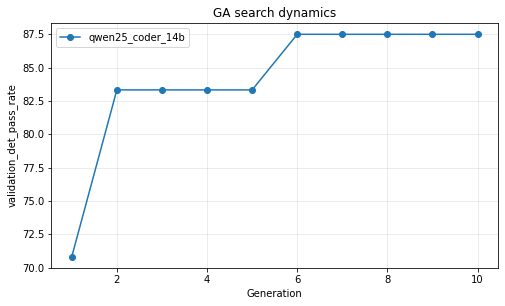

In [49]:
plot_ga_dynamics(out_ga_qwen14_allcat)

columns: ['profile', 'generation', 'model_key', 'genome_id', 'parent_ids', 'model', 'fitness', 'avg_det_score', 'det_pass_rate', 'det_variance', 'avg_prompt_tokens', 'strict_sdet', 'replay_fit', 'schema_fail_rate', 'train_avg_det_score', 'train_det_pass_rate', 'validation_avg_det_score', 'validation_det_pass_rate', 'validation_gt_exact_rate', 'candidate_strategies', 'active_core_blocks', 'active_optional_blocks', 'mutation_types', 'crossover_used', 'advisor_used', 'feedback_types_used', 'promoted_candidate']


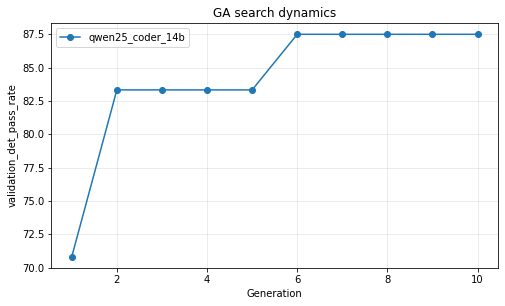

In [50]:
plot_ga_dynamics(out_ga_qwen14_allcat)

/tmp/ipykernel_5566/1843740074.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


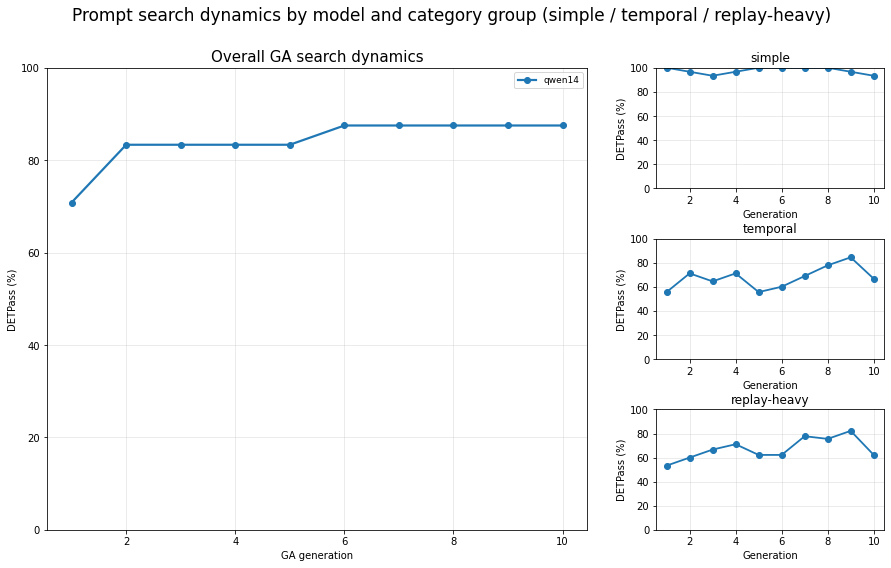

In [59]:
fig = plot_ga_dynamics_with_category_panels(
    runs={
        "qwen14": out_ga_qwen14_allcat,
    },
    save_path=Path(out_ga_qwen14_allcat).parent / "figure_ga_dynamics_by_category.png",
    label_mode="legacy", #paper
)

/tmp/ipykernel_5566/4025494341.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


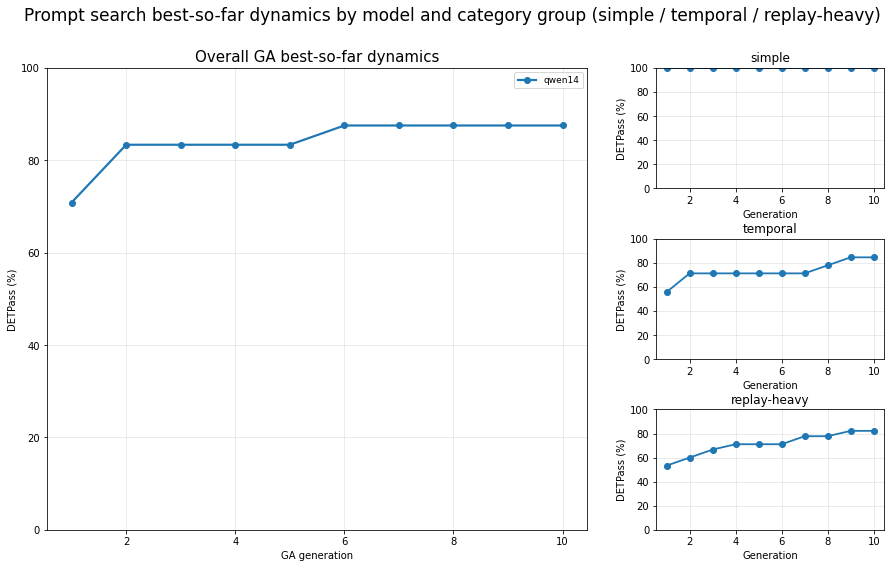

In [60]:
fig, overall_curve, category_curve = plot_ga_best_so_far_with_category_panels(
    runs={
        "qwen14": out_ga_qwen14_allcat,
    },
    save_path=Path(out_ga_qwen14_allcat).parent / "figure_ga_best_so_far_by_category.png",
    label_mode="legacy", #label_mode="paper",
)

In [63]:
# 기존에 실행 완료된 14B 결과 추가
ga_runs["14B"] = out_ga_qwen14_allcat

# 성공한 결과만 사용
valid_ga_runs = {
    label: path
    for label, path in ga_runs.items()
    if path is not None
}

valid_ga_runs

{'7B': PosixPath('/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/ga_output'),
 '8B': PosixPath('/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_llama31_8b_20260520_060611/ga_output'),
 '14B': PosixPath('/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_14b_20260518_222332/ga_output')}

/tmp/ipykernel_5566/4025494341.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


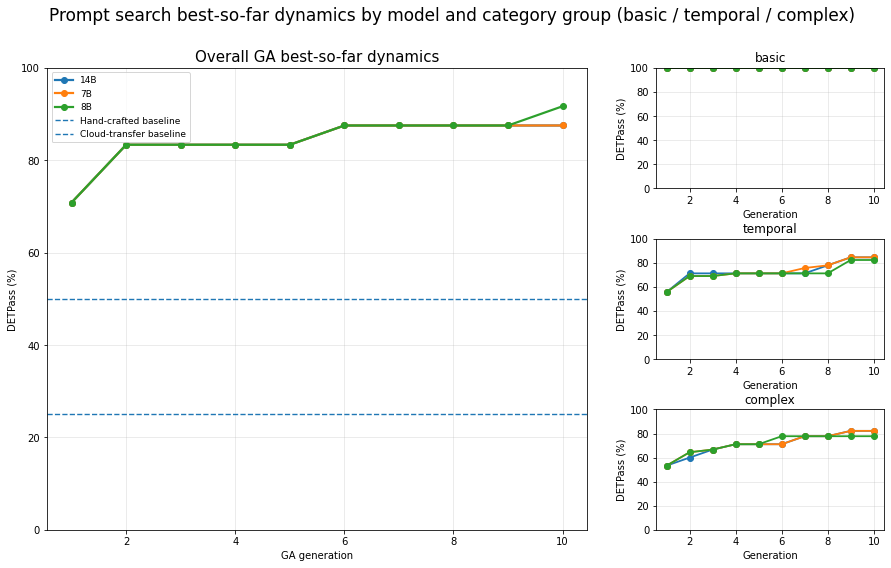

In [64]:
fig, overall_curve, category_curve = plot_ga_best_so_far_with_category_panels(
    runs=valid_ga_runs,
    save_path=RESULTS_ROOT / "figure_ga_best_so_far_7B_8B_14B_basic_temporal_complex.png",
    label_mode="paper",
    hand_crafted_baseline=25.0,
    cloud_transfer_baseline=50.0,
)

In [66]:
import json
from pathlib import Path
import pandas as pd

for label, path in valid_ga_runs.items():
    path = Path(path)
    manifest = path / "ga_run_manifest.json"
    progress = path / "ga_generation_progress.csv"

    print("\n==", label, "==")
    print("path:", path)

    if manifest.exists():
        m = json.loads(manifest.read_text())
        print("manifest model_key:", m.get("model_key"))
        print("model_label:", m.get("model_label"))
        print("command model part:", [x for x in m.get("command", "").split() if "model" in x or "qwen" in x or "llama" in x])
    else:
        print("[MISSING]", manifest)

    if progress.exists():
        df = pd.read_csv(progress)
        print("progress model_key unique:", df["model_key"].unique() if "model_key" in df.columns else "NO model_key")
        print(df[["generation", "model_key", "validation_det_pass_rate", "validation_avg_det_score", "genome_id"]].head(3))
    else:
        print("[MISSING]", progress)


== 7B ==
path: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/ga_output
manifest model_key: qwen25_coder_7b
model_label: Qwen2.5-Coder-7B-Instruct
command model part: ['--model-key', 'qwen25_coder_7b', '/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/ga_output']
progress model_key unique: ['qwen25_coder_7b']
   generation        model_key  validation_det_pass_rate  \
0           1  qwen25_coder_7b                   70.8333   
1           2  qwen25_coder_7b                   83.3333   
2           3  qwen25_coder_7b                   83.3333   

   validation_avg_det_score                                 genome_id  
0                   87.9273  gen-bbf8b961-f83c-3169-009b-831460788576  
1                   90.7404  gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275  
2                   90.7404  gen-850d8fe7-1f4e-6869-3fc0-fada9a20a275  

== 8B ==
p

In [67]:
import json
import hashlib
from pathlib import Path
import pandas as pd


def _json_load_maybe(value, default=None):
    try:
        return json.loads(value)
    except Exception:
        return default


def inspect_actual_llm_used(valid_ga_runs, generation=1):
    for label, path in valid_ga_runs.items():
        path = Path(path)

        progress = pd.read_csv(path / "ga_generation_progress.csv")
        row = progress[progress["generation"] == generation].iloc[0]
        genome_id = row["genome_id"]

        print("\n" + "=" * 80)
        print(f"== {label} ==")
        print("ga_output:", path)
        print("progress model_key:", row.get("model_key", ""))
        print("generation:", generation)
        print("best genome_id:", genome_id)
        print("validation_det_pass_rate:", row.get("validation_det_pass_rate"))
        print("validation_avg_det_score:", row.get("validation_avg_det_score"))

        candidates = sorted((path / "candidates").glob(f"candidates_ga_validation_{genome_id}_*.csv"))
        if not candidates:
            print("[WARN] no validation candidate csv for", genome_id)
            continue

        cand_path = candidates[0]
        print("candidate csv:", cand_path.name)

        df = pd.read_csv(cand_path)
        print("candidate rows:", len(df))

        cols = [
            "llm_mode",
            "llm_model",
            "generation_status",
            "generation_error_count",
            "generation_error_type",
            "generation_prompt_tokens_total",
            "generation_peak_vram_gb",
        ]
        print(df[[c for c in cols if c in df.columns]].head(3))

        # 후보 output hash 비교용
        joined_candidates = "\n".join(str(x) for x in df.get("candidates", []))
        print("candidate_hash:", hashlib.sha256(joined_candidates.encode("utf-8")).hexdigest()[:16])

        # 첫 row의 실제 prompt log를 열어서 resolved_local_model_name 확인
        if "prompt_log_paths" not in df.columns:
            print("[WARN] prompt_log_paths missing")
            continue

        paths = _json_load_maybe(df.iloc[0]["prompt_log_paths"], [])
        if not paths:
            print("[WARN] no prompt_log_paths in first row")
            continue

        log_path = Path(paths[0])
        print("first prompt log:", log_path)

        if not log_path.exists():
            print("[WARN] prompt log does not exist")
            continue

        payload = json.loads(log_path.read_text())
        req = payload.get("request", {})
        resp = payload.get("response", {})

        print("request mode:", req.get("mode"))
        print("request model:", req.get("model"))
        print("resolved_local_model_name:", req.get("resolved_local_model_name"))
        print("worker_path:", req.get("worker_path"))
        print("worker_python:", req.get("worker_python"))
        print("persistent_worker:", req.get("persistent_worker"))
        print("local_device:", req.get("local_device"))
        print("local_load_in_4bit:", req.get("local_load_in_4bit"))
        print("response worker_pid:", resp.get("worker_pid"))
        print("response prompt_tokens:", resp.get("prompt_tokens"))
        print("response peak_vram_gb:", resp.get("peak_vram_gb"))

        content = str(resp.get("content", ""))
        print("response_hash:", hashlib.sha256(content.encode("utf-8")).hexdigest()[:16])
        print("response_head:", content[:200].replace("\n", " "))

In [68]:
inspect_actual_llm_used(valid_ga_runs, generation=1)


== 7B ==
ga_output: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat3_pop5_gens10_qwen25_coder_7b_20260519_184152/ga_output
progress model_key: qwen25_coder_7b
generation: 1
best genome_id: gen-bbf8b961-f83c-3169-009b-831460788576
validation_det_pass_rate: 70.8333
validation_avg_det_score: 87.9273
candidate csv: candidates_ga_validation_gen-bbf8b961-f83c-3169-009b-831460788576_501160.csv
candidate rows: 24
  llm_mode                       llm_model generation_status  \
0   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
1   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   
2   worker  Qwen/Qwen2.5-Coder-7B-Instruct                ok   

   generation_error_count  generation_error_type  \
0                       0                    NaN   
1                       0                    NaN   
2                       0                    NaN   

   generation_prompt_tokens_total  generation_peak_vram_gb  
0                           75449 

In [70]:
!env | grep -E 'JOI_V15_LOCAL_MODEL_NAME|JOI_V14_LOCAL_MODEL_NAME|JOI_V15_LOCAL_MODEL_BASE_DIR|JOI_V14_LOCAL_MODEL_BASE_DIR|JOI_V15_MODEL|JOI_V14_MODEL' | sort

|=grep -E 'JOI_V15_LOCAL_MODEL_NAME|JOI_V14_LOCAL_MODEL_NAME|JOI_V15_LOCAL_MODEL_BASE_DIR|JOI_V14_LOCAL_MODEL_BASE_DIR|JOI_V15_MODEL|JOI_V14_MODEL' | sort
JOI_V15_LOCAL_MODEL_BASE_DIR=/root/llm/JOILang-Server/local_models
JOI_V15_LOCAL_MODEL_NAME=/root/llm/JOILang-Server/local_models/qwen25_coder_7b


RUN_ROOT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_183813
GA_OUTPUT: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_183813/ga_output
WATCHDOG: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_183813/_watchdog_logs
COMMAND: /usr/bin/python3 -u /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/scripts/run_ga_search.py --profile version0_15 --model-key qwen25_coder_7b --population 2 --gens 1 --sample-size 8 --validation-size 8 --cheap-eval-limit 2 --candidate-k 1 --repair-attempts 0 --det-profile strict --feedback-guided-mutation --progress verbose --timeout-sec 600 --retries 0 --output-root /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/smoke_allcat1_pop2_gens1_qwen25_coder_7b_20260520_183813/ga_output --category 1 --category 2 --category 3 --catego

OSError: [Errno 28] No space left on device

In [ ]:
import hashlib
from pathlib import Path

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

for label, path in valid_ga_runs.items():
    path = Path(path)
    cand_files = sorted((path / "candidates").glob("candidates_ga_validation_*.csv"))
    print("\n==", label, "==")
    print("num validation candidate files:", len(cand_files))
    for f in cand_files[:3]:
        print(f.name, sha256_file(f)[:16])

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def _to_percent(s: pd.Series) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    if s.dropna().max() is not None and s.dropna().max() <= 1.000001:
        return s * 100.0
    return s


def _pick_y_col(df: pd.DataFrame) -> str:
    for c in [
        "validation_det_pass_rate",
        "det_pass_rate",
        "DETPass",
        "mean_DETPass",
        "validation_avg_det_score",
        "avg_det_score",
        "fitness",
    ]:
        if c in df.columns:
            return c
    raise ValueError(f"No usable DET/pass metric column found. columns={list(df.columns)}")


def _load_generation_progress(out_dirs: dict[str, str | Path]) -> pd.DataFrame:
    frames = []

    for label, out_dir in out_dirs.items():
        out_dir = Path(out_dir)

        candidates = [
            out_dir / "ga_generation_progress.csv",
            out_dir / "paper" / "figure_data" / "figure1_generation_dynamics.csv",
            out_dir / "figure_data" / "figure1_generation_dynamics.csv",
        ]

        path = next((p for p in candidates if p.exists()), None)
        if path is None:
            print(f"[WARN] no generation progress csv for {label}: {out_dir}")
            continue

        df = pd.read_csv(path)
        df["model_label_for_plot"] = label
        if "model_key" not in df.columns:
            df["model_key"] = label
        frames.append(df)

    if not frames:
        raise FileNotFoundError("No ga_generation_progress.csv or figure1_generation_dynamics.csv found.")

    return pd.concat(frames, ignore_index=True)


def _load_category_diagnostics(out_dirs: dict[str, str | Path]) -> pd.DataFrame:
    frames = []

    for label, out_dir in out_dirs.items():
        out_dir = Path(out_dir)

        candidates = [
            out_dir / "ga_population_diagnostics.csv",
            out_dir / "paper" / "figure_data" / "figure1_category_dynamics.csv",
            out_dir / "figure_data" / "figure1_category_dynamics.csv",
        ]

        path = next((p for p in candidates if p.exists()), None)
        if path is None:
            print(f"[WARN] no category diagnostic csv for {label}: {out_dir}")
            continue

        df = pd.read_csv(path)
        df["model_label_for_plot"] = label
        if "model_key" not in df.columns:
            df["model_key"] = label
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    return pd.concat(frames, ignore_index=True)


def _category_group(category) -> str:
    token = str(category).strip()

    if token in {"1", "2"}:
        return "Basic"
    if token in {"3", "4", "5"}:
        return "Temporal"
    if token in {"6", "7", "8"}:
        return "Complex"

    return f"Category {token}"


def _weighted_group_mean(df: pd.DataFrame, y_col: str) -> pd.DataFrame:
    df = df.copy()
    df[y_col] = _to_percent(df[y_col])

    if "row_evaluations" in df.columns:
        df["row_evaluations"] = pd.to_numeric(df["row_evaluations"], errors="coerce").fillna(1.0)

        rows = []
        for keys, sub in df.groupby(["model_label_for_plot", "group", "generation"], dropna=False):
            weight = sub["row_evaluations"]
            y = sub[y_col]
            if weight.sum() > 0:
                mean_y = (y * weight).sum() / weight.sum()
            else:
                mean_y = y.mean()
            rows.append(
                {
                    "model_label_for_plot": keys[0],
                    "group": keys[1],
                    "generation": keys[2],
                    y_col: mean_y,
                }
            )
        return pd.DataFrame(rows)

    return (
        df.groupby(["model_label_for_plot", "group", "generation"], as_index=False)[y_col]
        .mean()
    )


def plot_paper_ga_dynamics(
    out_dirs: dict[str, str | Path],
    save_path: str | Path | None = None,
    title: str = "Figure 1. Prompt Search Dynamics Across Model Scales",
    hand_crafted_baseline: float | None = 25.0,
    cloud_transfer_baseline: float | None = 50.0,
):
    """
    out_dirs example:
        {
            "4B": "/path/to/ga_allcat_phi35_mini_...",
            "7B": "/path/to/ga_allcat_qwen25_coder_7b_...",
            "14B": "/path/to/ga_allcat_qwen25_coder_14b_...",
        }

    Required for left panel:
        ga_generation_progress.csv

    Required for right category panels:
        ga_population_diagnostics.csv
        or figure1_category_dynamics.csv
    """

    gen_df = _load_generation_progress(out_dirs)
    y_col = _pick_y_col(gen_df)

    if "generation" not in gen_df.columns:
        raise ValueError("generation column is required.")

    gen_df = gen_df.copy()
    gen_df["generation"] = pd.to_numeric(gen_df["generation"], errors="coerce")
    gen_df[y_col] = _to_percent(gen_df[y_col])

    overall = (
        gen_df.groupby(["model_label_for_plot", "generation"], as_index=False)[y_col]
        .mean()
        .dropna(subset=["generation", y_col])
    )

    cat_df = _load_category_diagnostics(out_dirs)

    fig = plt.figure(figsize=(15, 9))
    gs = GridSpec(
        nrows=3,
        ncols=2,
        width_ratios=[3.2, 1.25],
        height_ratios=[1, 1, 1],
        wspace=0.15,
        hspace=0.5,
    )

    ax_main = fig.add_subplot(gs[:, 0])
    ax_basic = fig.add_subplot(gs[0, 1])
    ax_temporal = fig.add_subplot(gs[1, 1])
    ax_complex = fig.add_subplot(gs[2, 1])

    axes_by_group = {
        "Basic": ax_basic,
        "Temporal": ax_temporal,
        "Complex": ax_complex,
    }

    # Left main panel
    for label, sub in overall.groupby("model_label_for_plot"):
        sub = sub.sort_values("generation")
        ax_main.plot(sub["generation"], sub[y_col], linewidth=2.5, label=label)

    if hand_crafted_baseline is not None:
        ax_main.axhline(hand_crafted_baseline, linestyle="--", linewidth=1.5, label="Hand-crafted baseline")

    if cloud_transfer_baseline is not None:
        ax_main.axhline(cloud_transfer_baseline, linestyle="--", linewidth=1.5, label="Cloud-transfer baseline")

    ax_main.set_xlabel("GA Generation", fontsize=14)
    ax_main.set_ylabel("DETPass (%)", fontsize=14)
    ax_main.set_ylim(0, 100)
    ax_main.grid(True, alpha=0.35)
    ax_main.legend(loc="lower right", fontsize=10)

    # Optional paper-style annotations
    ax_main.annotate(
        "Fast early gains",
        xy=(8, 73),
        xytext=(4, 85),
        arrowprops={"arrowstyle": "->", "linewidth": 1.0},
        fontsize=11,
        fontstyle="italic",
    )

    ax_main.annotate(
        "Late crossover",
        xy=(34, 82),
        xytext=(36, 72),
        arrowprops={"arrowstyle": "->", "linewidth": 1.0},
        fontsize=11,
        fontstyle="italic",
    )

    # Right category panels
    if not cat_df.empty and "generation" in cat_df.columns and "category" in cat_df.columns:
        cat_df = cat_df.copy()
        cat_df["generation"] = pd.to_numeric(cat_df["generation"], errors="coerce")
        cat_df["group"] = cat_df["category"].map(_category_group)

        cat_y = _pick_y_col(cat_df)
        cat_grouped = _weighted_group_mean(cat_df, cat_y).dropna(subset=["generation", cat_y])

        for group_name, ax in axes_by_group.items():
            group_data = cat_grouped[cat_grouped["group"] == group_name]

            for label, sub in group_data.groupby("model_label_for_plot"):
                sub = sub.sort_values("generation")
                ax.plot(sub["generation"], sub[cat_y], linewidth=2.0)

            ax.set_title(group_name, fontsize=13)
            ax.set_xlabel("GA Generation", fontsize=10)
            ax.set_ylabel("DETPass (%)", fontsize=10)
            ax.set_ylim(0, 100)
            ax.grid(True, alpha=0.35)
    else:
        for group_name, ax in axes_by_group.items():
            ax.set_title(group_name, fontsize=13)
            ax.text(
                0.5,
                0.5,
                "No category\n diagnostics",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_ylim(0, 100)
            ax.grid(True, alpha=0.35)

    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=220, bbox_inches="tight")

        if save_path.suffix.lower() != ".pdf":
            fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")

    plt.show()
    return fig

In [33]:
plot_paper_ga_dynamics(
    {
        "4B": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat_phi35_mini_YYYYMMDD_HHMMSS",
        "7B": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat_qwen25_coder_7b_YYYYMMDD_HHMMSS",
        "14B": "/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat_qwen25_coder_14b_YYYYMMDD_HHMMSS",
    },
    save_path="/root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/paper_figure1_basic_temporal_complex.png",
    hand_crafted_baseline=25.0,
    cloud_transfer_baseline=50.0,
)

[WARN] no generation progress csv for 4B: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat_phi35_mini_YYYYMMDD_HHMMSS
[WARN] no generation progress csv for 7B: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat_qwen25_coder_7b_YYYYMMDD_HHMMSS
[WARN] no generation progress csv for 14B: /root/llm/JOILang-Server/gpt_mg/version0_15_update20260413/results/ga_allcat_qwen25_coder_14b_YYYYMMDD_HHMMSS


FileNotFoundError: No ga_generation_progress.csv or figure1_generation_dynamics.csv found.